# ANÁLISE E MODELAGEM PREDITIVA DE ARBOVIROSE (DENGUE) - DF
## Target Epidemiológico, Lags Climáticos, Validação sem Leakage, Ablação e Modelagem Preditiva

Este notebook é uma versão **100% executável localmente com outputs e visualizações completas**, com estrutura e rigor estético baseados no padrão de modelagem do notebook `roger-quinelato-ciia-2026 (1).ipynb`.

O pipeline está estruturado passo a passo, cobrindo:
1. **Formalização e Análise do Target**: Comparação de filtros de sementes epidemiológicas.
2. **Engenharia de Features e Lags**: Cruzamento climáticos (temperatura, umidade, chuva) com atrasos temporais.
3. **Análise Exploratória Visual**: Séries temporais, volumetria por Região Administrativa (RA), heatmaps temporais e correlações.
4. **Validação em Janela Móvel (Rolling Validation)**: Avaliação robusta temporal sem leakage de dados futuros.
5. **Estudo de Ablação**: Teste de hipóteses estruturado avaliando o ganho marginal de cada grupo de features.
6. **Tuning de Hiperparâmetros**: Ajuste fino de modelos Random Forest e XGBoost.
7. **Validação Federal (SINAN vs info-saude)**: Validação de compatibilidade histórica (2017) para splicing futuro.


# ==================================================================================
# CÉLULA 1: SETUP, IMPORTS E CONFIGURAÇÕES
# ==================================================================================


In [1]:

# CÉLULA 1: SETUP, IMPORTS E CONFIGURAÇÕES
# ============================================================================
import warnings
warnings.filterwarnings('ignore')
from pathlib import Path
import sys
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from IPython.display import Image, display

# Detecta dinamicamente a pasta raiz do projeto
BASE = Path('.').resolve()
sys.path.append(str(BASE))
sys.path.append(str(BASE / 'scripts'))
import executar_plano_prompts_opus as p

# Configurações globais de plotagem
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (14, 6)
plt.rcParams['font.size'] = 11

print("=" * 80)
print("DENGUE DF - AMBIENTE DE ANÁLISE E MODELAGEM INICIALIZADO")
print("=" * 80)
print(f"Raiz do Projeto Detectada: {BASE.absolute()}")
print(f"Data/Hora da Execução: {pd.Timestamp.now()}\n")


DENGUE DF - AMBIENTE DE ANÁLISE E MODELAGEM INICIALIZADO
Raiz do Projeto Detectada: C:\arbodf\DocML
Data/Hora da Execução: 2026-05-24 23:26:12.930113



# ==================================================================================
# CÉLULA 2: ANÁLISE E FORMALIZAÇÃO DO TARGET EPIDEMIOLÓGICO
# ==================================================================================


PASSO 1: ANÁLISE E FORMALIZAÇÃO DO TARGET EPIDEMIOLÓGICO
>>> P0/P1: formalizando target epidemiologico...

[DECISÃO E FORMALIZAÇÃO DO TARGET]
--------------------------------------------------------------------------------
• Target Selecionado: familia_dengue
• Filtro Aplicado: i_class_final == 'Caso Provavel' AND i_desc_classificacao in ['Dengue', 'Dengue com sinais de alarme', 'Dengue grave']
• Recomendação Técnica: Usar familia_dengue: remove Inconclusivo/Nao Informado, preserva dengue grave e dengue com sinais de alarme, e fica semanticamente mais perto da familia de codigos de dengue observada no SINAN.

[DISTRIBUIÇÃO DE CASOS POR ANO E FILTRO]
--------------------------------------------------------------------------------

[VISUALIZAÇÃO DE COMPATIBILIDADE DOS FILTROS]
--------------------------------------------------------------------------------


,ano,filtro_simples,filtro_duplo_dengue_exata,filtro_familia_dengue
0,1900,1,1,1
1,1938,1,1,1
2,1956,1,1,1
3,1978,1,1,1
4,1982,1,1,1
5,1991,1,1,1
6,2016,1,1,1
7,2017,4533,3099,3264
8,2018,2691,1479,1523
9,2019,46974,35032,36180


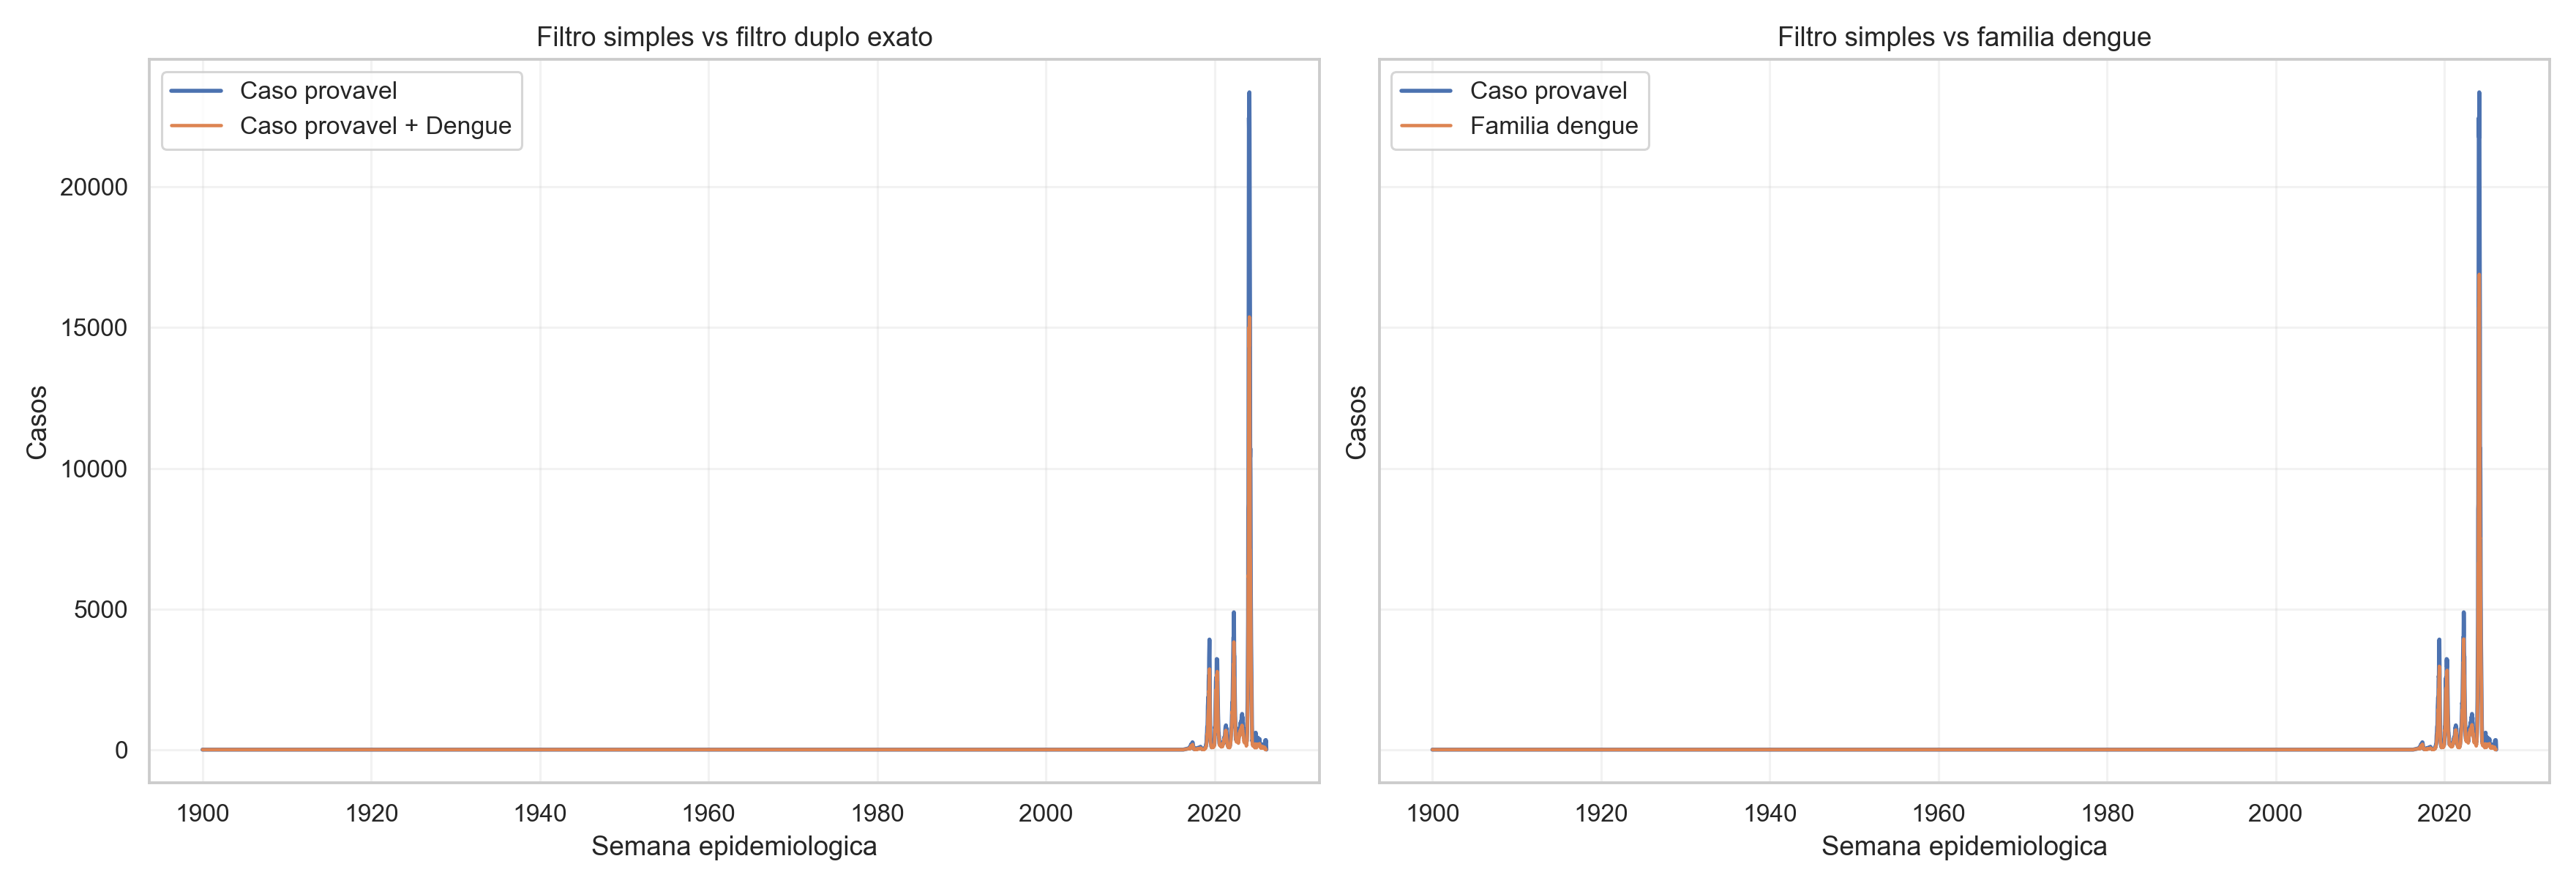

In [2]:

# CÉLULA 2: ANÁLISE E FORMALIZAÇÃO DO TARGET
# ============================================================================
print("=" * 80)
print("PASSO 1: ANÁLISE E FORMALIZAÇÃO DO TARGET EPIDEMIOLÓGICO")
print("=" * 80)

# Executar a análise de target
target_annual, target_decision = p.run_prompt1_target_analysis()

print("\n[DECISÃO E FORMALIZAÇÃO DO TARGET]")
print("-" * 80)
print(f"• Target Selecionado: {target_decision['target_name']}")
print(f"• Filtro Aplicado: {target_decision['target_filter']}")
print(f"• Recomendação Técnica: {target_decision['recommendation']}")

print("\n[DISTRIBUIÇÃO DE CASOS POR ANO E FILTRO]")
print("-" * 80)
display(target_annual)

print("\n[VISUALIZAÇÃO DE COMPATIBILIDADE DOS FILTROS]")
print("-" * 80)
display(Image(filename='resultados_graficos/target_comparativo.png'))


# ==================================================================================
# CÉLULA 3: CARREGAMENTO DO DATASET INTEGRADO (CASOS, CLIMA E POPULAÇÃO)
# ==================================================================================


In [3]:

# CÉLULA 3: CARREGAMENTO DO DATASET INTEGRADO
# ============================================================================
print("=" * 80)
print("PASSO 2: CARREGAMENTO DO DATASET INTEGRADO (CASOS, CLIMA E POPULAÇÃO)")
print("=" * 80)

dataset = p.build_processed_dataset(target_decision['target_name'])

print(f"\n✓ Dataset integrado criado e carregado: {dataset.shape[0]:,} linhas, {dataset.shape[1]} colunas.")
print("\nPrimeiros Registros do Dataset Processado:")
print("-" * 80)
display(dataset.head())


PASSO 2: CARREGAMENTO DO DATASET INTEGRADO (CASOS, CLIMA E POPULAÇÃO)
>>> P1: gerando graficos de EDA...

✓ Dataset integrado criado e carregado: 16,730 linhas, 48 colunas.

Primeiros Registros do Dataset Processado:
--------------------------------------------------------------------------------


,epi_sunday,RA,cases,ano,populacao,incidencia_100k,temp_max,temp_min,temp_mean,precip_sum,umidmed,umidmin,umidmax,cases_lag_1,cases_lag_2,cases_lag_3,cases_lag_4,incidencia_100k_lag_1,incidencia_100k_lag_2,incidencia_100k_lag_3,incidencia_100k_lag_4,precip_sum_lag_2,precip_sum_lag_3,precip_sum_lag_4,precip_sum_lag_5,precip_sum_lag_6,precip_sum_lag_7,precip_sum_lag_8,temp_mean_lag_2,temp_mean_lag_3,temp_mean_lag_4,temp_mean_lag_5,temp_mean_lag_6,temp_mean_lag_7,temp_mean_lag_8,umidmed_lag_2,umidmed_lag_3,umidmed_lag_4,umidmed_lag_5,umidmed_lag_6,umidmed_lag_7,umidmed_lag_8,week_of_year,month,sin_week,cos_week,sin_month,cos_month
0,2017-01-01,AGUA QUENTE,0.0,2017,10342,0.0,28.971429,19.571429,24.257143,18.6,72.289117,56.285714,87.428571,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,52,1,-0.118273,0.992981,0.5,0.866025
1,2017-01-08,AGUA QUENTE,0.0,2017,10342,0.0,28.842857,20.100000,24.071429,17.2,83.311720,68.857143,90.714286,0.0,NaN,NaN,NaN,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1,1,0.118273,0.992981,0.5,0.866025
2,2017-01-15,AGUA QUENTE,0.0,2017,10342,0.0,25.814286,19.414286,22.042857,46.8,85.686888,66.571429,94.857143,0.0,0.0,NaN,NaN,0.0,0.0,NaN,NaN,18.6,NaN,NaN,NaN,NaN,NaN,NaN,24.257143,NaN,NaN,NaN,NaN,NaN,NaN,72.289117,NaN,NaN,NaN,NaN,NaN,NaN,2,1,0.234886,0.972023,0.5,0.866025
3,2017-01-22,AGUA QUENTE,0.0,2017,10342,0.0,26.514286,18.685714,22.371429,37.5,85.958504,73.857143,96.000000,0.0,0.0,0.0,NaN,0.0,0.0,0.0,NaN,17.2,18.6,NaN,NaN,NaN,NaN,NaN,24.071429,24.257143,NaN,NaN,NaN,NaN,NaN,83.311720,72.289117,NaN,NaN,NaN,NaN,NaN,3,1,0.348202,0.937420,0.5,0.866025
4,2017-01-29,AGUA QUENTE,0.0,2017,10342,0.0,27.328571,19.414286,23.014286,20.8,83.324500,74.428571,90.714286,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,46.8,17.2,18.6,NaN,NaN,NaN,NaN,22.042857,24.071429,24.257143,NaN,NaN,NaN,NaN,85.686888,83.311720,72.289117,NaN,NaN,NaN,NaN,4,1,0.456629,0.889657,0.5,0.866025


# ==================================================================================
# CÉLULA 4: ANÁLISE DE QUALIDADE DOS DADOS (MISSING VALUES E DESCRITIVOS)
# ==================================================================================


In [4]:

# CÉLULA 4: ANÁLISE DE QUALIDADE DOS DADOS
# ============================================================================
print("=" * 80)
print("PASSO 3: ANÁLISE DE QUALIDADE E DESCRITIVOS DAS FEATURES")
print("=" * 80)

# Análise de nulos
null_counts = dataset.isnull().sum()
null_pct = (null_counts / len(dataset)) * 100
quality_df = pd.DataFrame({
    'Valores Nulos': null_counts, 
    'Percentual (%)': null_pct
}).sort_values('Valores Nulos', ascending=False)

print("\n[DADOS AUSENTES NAS FEATURES]")
print("-" * 80)
colunas_com_nulos = quality_df[quality_df['Valores Nulos'] > 0]
if len(colunas_com_nulos) > 0:
    display(colunas_com_nulos)
else:
    print("✓ Fantástico! Nenhuma coluna possui valores ausentes/nulos.")

print("\n[ESTATÍSTICAS DESCRITIVAS GERAIS]")
print("-" * 80)
display(dataset.describe())


PASSO 3: ANÁLISE DE QUALIDADE E DESCRITIVOS DAS FEATURES

[DADOS AUSENTES NAS FEATURES]
--------------------------------------------------------------------------------

[ESTATÍSTICAS DESCRITIVAS GERAIS]
--------------------------------------------------------------------------------


,Valores Nulos,Percentual (%)
temp_mean_lag_8,280,1.673640
umidmed_lag_8,280,1.673640
precip_sum_lag_8,280,1.673640
precip_sum_lag_7,245,1.464435
umidmed_lag_7,245,1.464435
temp_mean_lag_7,245,1.464435
temp_mean_lag_6,210,1.255230
precip_sum_lag_6,210,1.255230
umidmed_lag_6,210,1.255230
precip_sum_lag_5,175,1.046025


,epi_sunday,cases,ano,populacao,incidencia_100k,temp_max,temp_min,temp_mean,precip_sum,umidmed,umidmin,umidmax,cases_lag_1,cases_lag_2,cases_lag_3,cases_lag_4,incidencia_100k_lag_1,incidencia_100k_lag_2,incidencia_100k_lag_3,incidencia_100k_lag_4,precip_sum_lag_2,precip_sum_lag_3,precip_sum_lag_4,precip_sum_lag_5,precip_sum_lag_6,precip_sum_lag_7,precip_sum_lag_8,temp_mean_lag_2,temp_mean_lag_3,temp_mean_lag_4,temp_mean_lag_5,temp_mean_lag_6,temp_mean_lag_7,temp_mean_lag_8,umidmed_lag_2,umidmed_lag_3,umidmed_lag_4,umidmed_lag_5,umidmed_lag_6,umidmed_lag_7,umidmed_lag_8,week_of_year,month,sin_week,cos_week,sin_month,cos_month
count,16730,16730.000000,16730.000000,16730.000000,16730.000000,16730.000000,16730.000000,16730.000000,16730.000000,16730.000000,16730.000000,16730.000000,16695.000000,16660.000000,16625.000000,16590.000000,16695.000000,16660.000000,16625.000000,16590.000000,16660.000000,16625.000000,16590.000000,16555.000000,16520.000000,16485.000000,16450.000000,16660.000000,16625.000000,16590.000000,16555.000000,16520.000000,16485.000000,16450.000000,16660.000000,16625.000000,16590.000000,16555.000000,16520.000000,16485.000000,16450.000000,16730.000000,16730.000000,16730.000000,16730.000000,1.673000e+04,1.673000e+04
mean,2021-07-28 12:00:00.000000256,9.237478,2021.079498,78891.486790,10.565874,26.966288,17.826091,21.997131,20.477197,69.630039,52.020867,85.028765,9.256843,9.276230,9.295759,9.315069,10.588024,10.610220,10.632557,10.654760,20.354832,20.346105,20.219831,20.208668,20.054237,20.071550,19.957021,21.996339,21.996602,21.996685,21.996678,21.998456,21.997028,21.999058,69.584407,69.561311,69.530292,69.510043,69.474091,69.474734,69.449285,26.240586,6.447699,0.007953,-0.000774,7.322176e-03,1.171146e-02
min,2017-01-01 00:00:00,0.000000,2017.000000,5150.000000,0.000000,21.971429,12.285714,16.800000,0.000000,26.174429,14.176829,39.968771,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,16.800000,16.800000,16.800000,16.800000,16.800000,16.800000,16.800000,26.174429,26.174429,26.174429,26.174429,26.174429,26.174429,26.174429,1.000000,1.000000,-0.999561,-0.998244,-1.000000e+00,-1.000000e+00
25%,2019-04-14 00:00:00,0.000000,2019.000000,27073.000000,0.000000,25.557143,16.500000,21.000000,0.100000,59.957454,38.480610,78.674153,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.100000,0.100000,0.100000,0.100000,0.100000,0.100000,0.100000,20.996429,20.985714,20.985714,20.985714,20.985714,20.985714,20.985714,59.927810,59.838878,59.838878,59.838878,59.835219,59.824243,59.824243,13.000000,3.000000,-0.696551,-0.717507,-5.000000e-01,-5.000000e-01
50%,2021-07-28 12:00:00,0.000000,2021.000000,64196.000000,0.000000,26.528571,18.414286,21.957143,8.450000,71.926262,52.744328,89.006906,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,8.250000,8.100000,8.000000,7.900000,7.850000,7.800000,7.700000,21.957143,21.957143,21.957143,21.957143,21.957143,21.957143,21.957143,71.809713,71.709920,71.697196,71.684473,71.634704,71.684473,71.634704,26.000000,6.000000,0.059241,0.029633,1.224647e-16,6.123234e-17
75%,2023-11-12 00:00:00,2.000000,2023.000000,112810.000000,3.738038,28.014286,19.271429,22.885714,33.300000,81.648041,64.919071,94.020300,2.000000,2.000000,2.000000,2.000000,3.745614,3.762121,3.778504,3.782864,33.000000,33.300000,32.900000,32.900000,32.750000,32.900000,32.700000,22.875000,22.885714,22.885714,22.885714,22.885714,22.885714,22.885714,81.570835,81.648041,81.545100,81.545100,81.527601,81.545100,81.545100,39.000000,9.000000,0.696551,0.674983,5.000000e-01,8.660254e-01
max,2026-02-22 00:00:00,1371.000000,2026.000000,294045.000000,1127.142681,34.414286,21.842857,28.100000,153.200000,92.156143,86.110409,100.000000,1371.000000,1371.000000,1371.000000,1371.000000,1127.142681,1127.142681,1127.142681,1127.142681,153.200000,153.200000,153.200000,153.200000,153.200000,153.200000,153.200000,28.100000,28.100000,28.10000

# ==================================================================================
# CÉLULA 5: ANÁLISE EXPLORATÓRIA - SÉRIES TEMPORAIS E VOLUMETRIA
# ==================================================================================


PASSO 4: SÉRIES TEMPORAIS, OUTLIERS E COMPARAÇÕES ENTRE RAs

📊 1. Série Temporal Consolidada do Distrito Federal (Picos Epidemiológicos):
--------------------------------------------------------------------------------

📊 2. Comparativo de Casos vs Incidência por 100k (Ceilândia vs Lago Sul):
--------------------------------------------------------------------------------

📊 3. Top 10 Regiões Administrativas por Volume Total de Casos:
--------------------------------------------------------------------------------


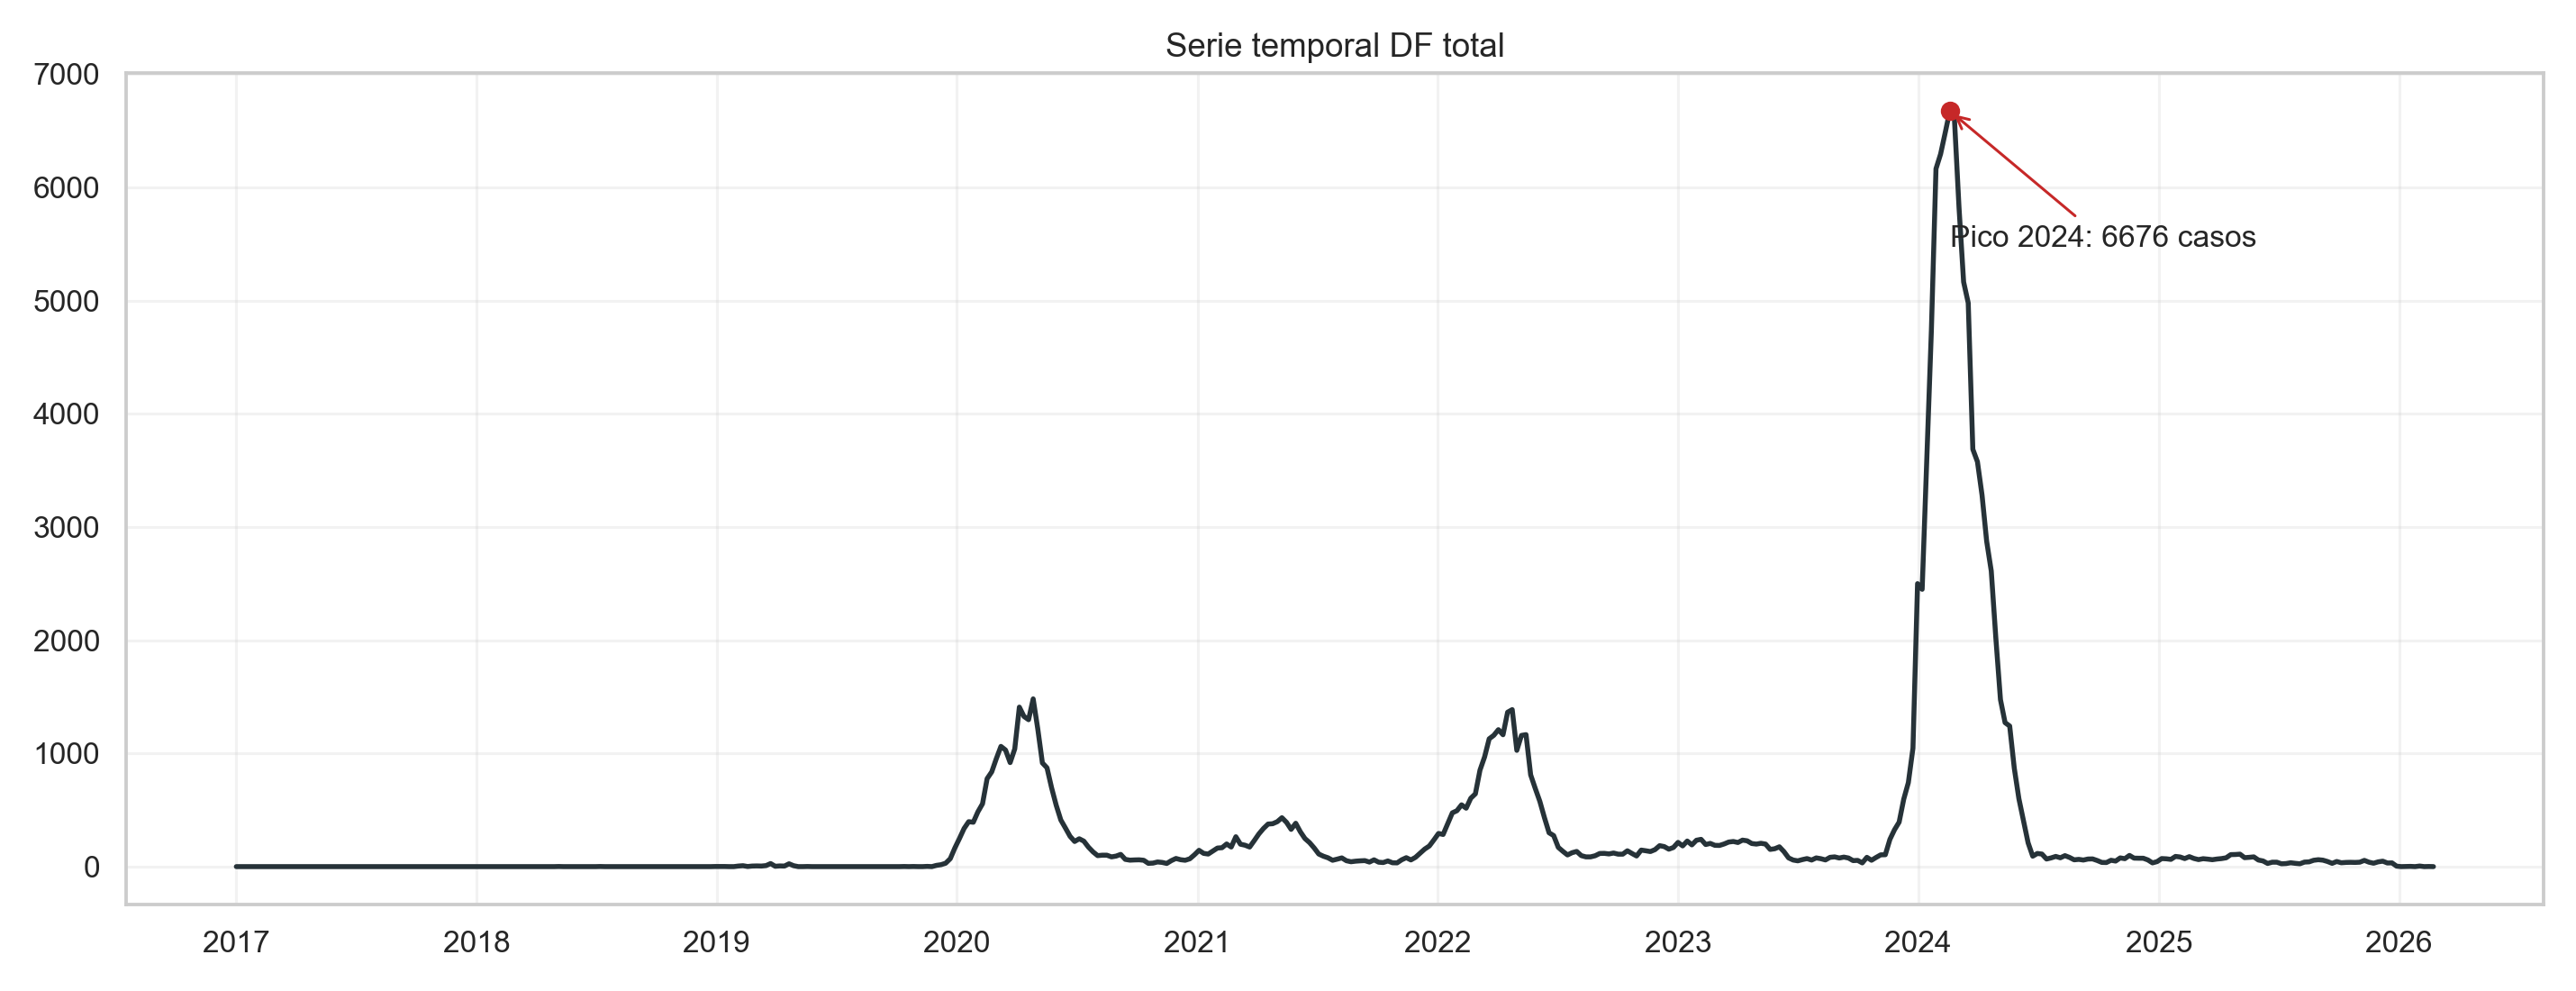

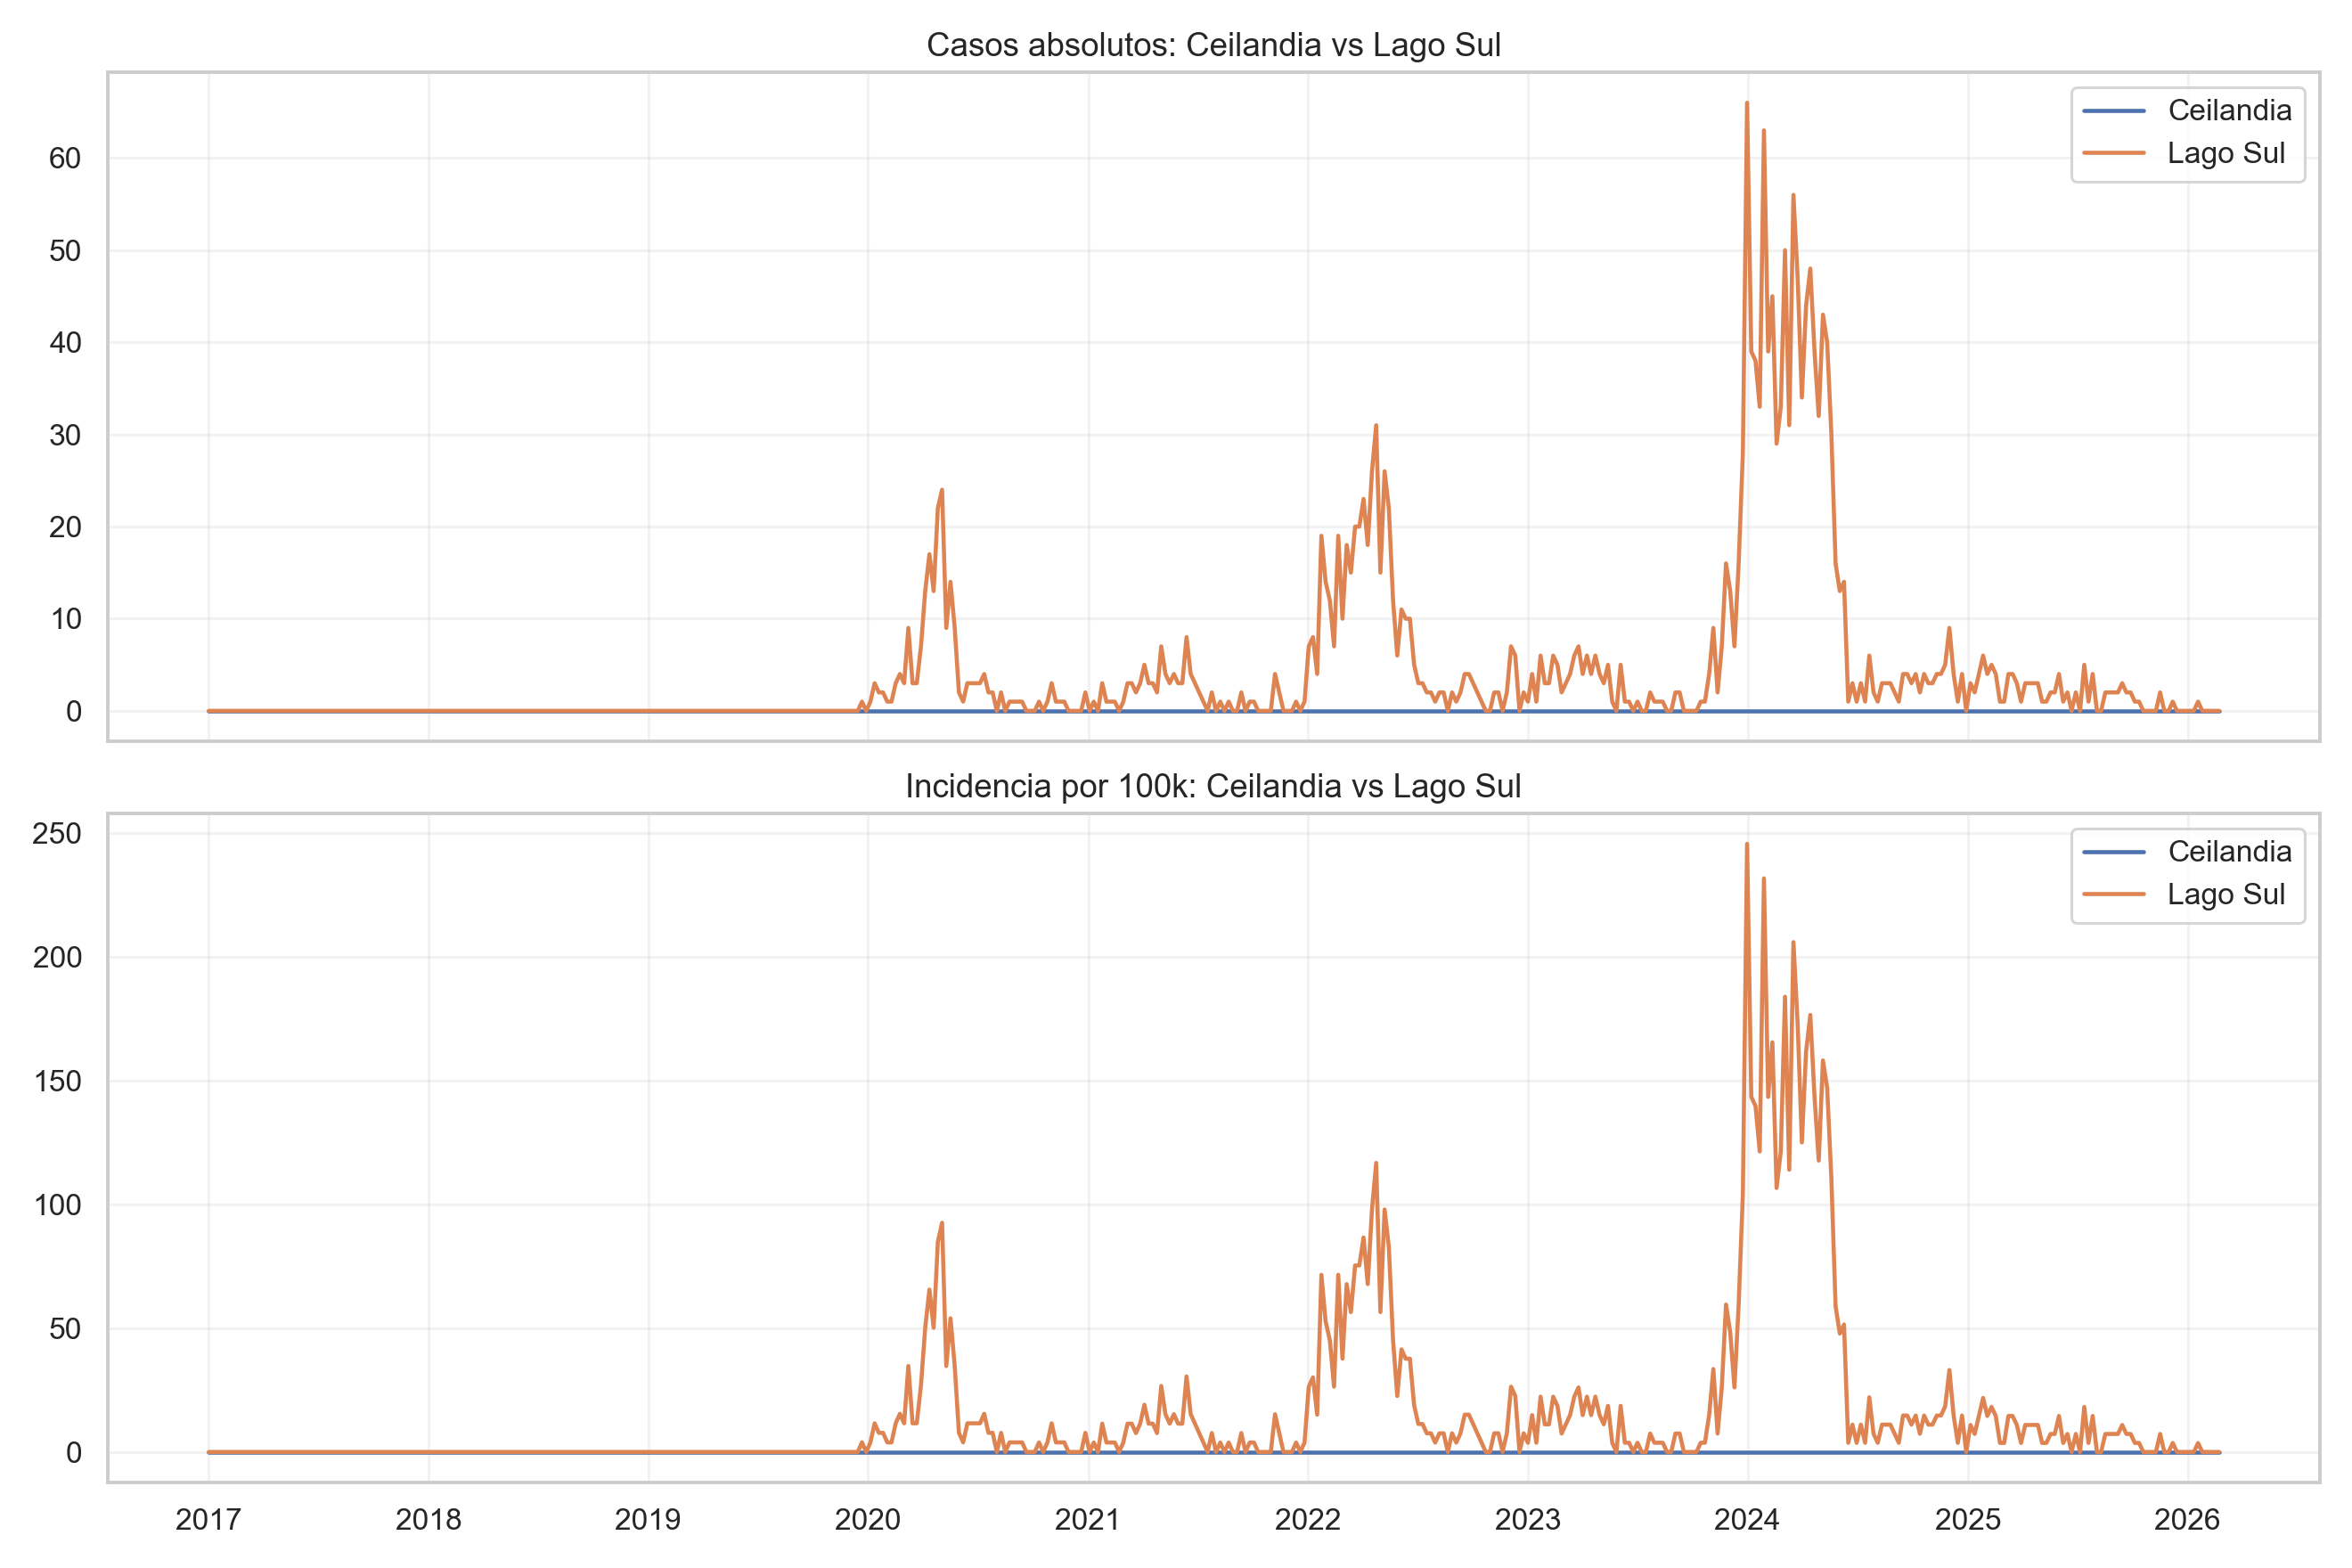

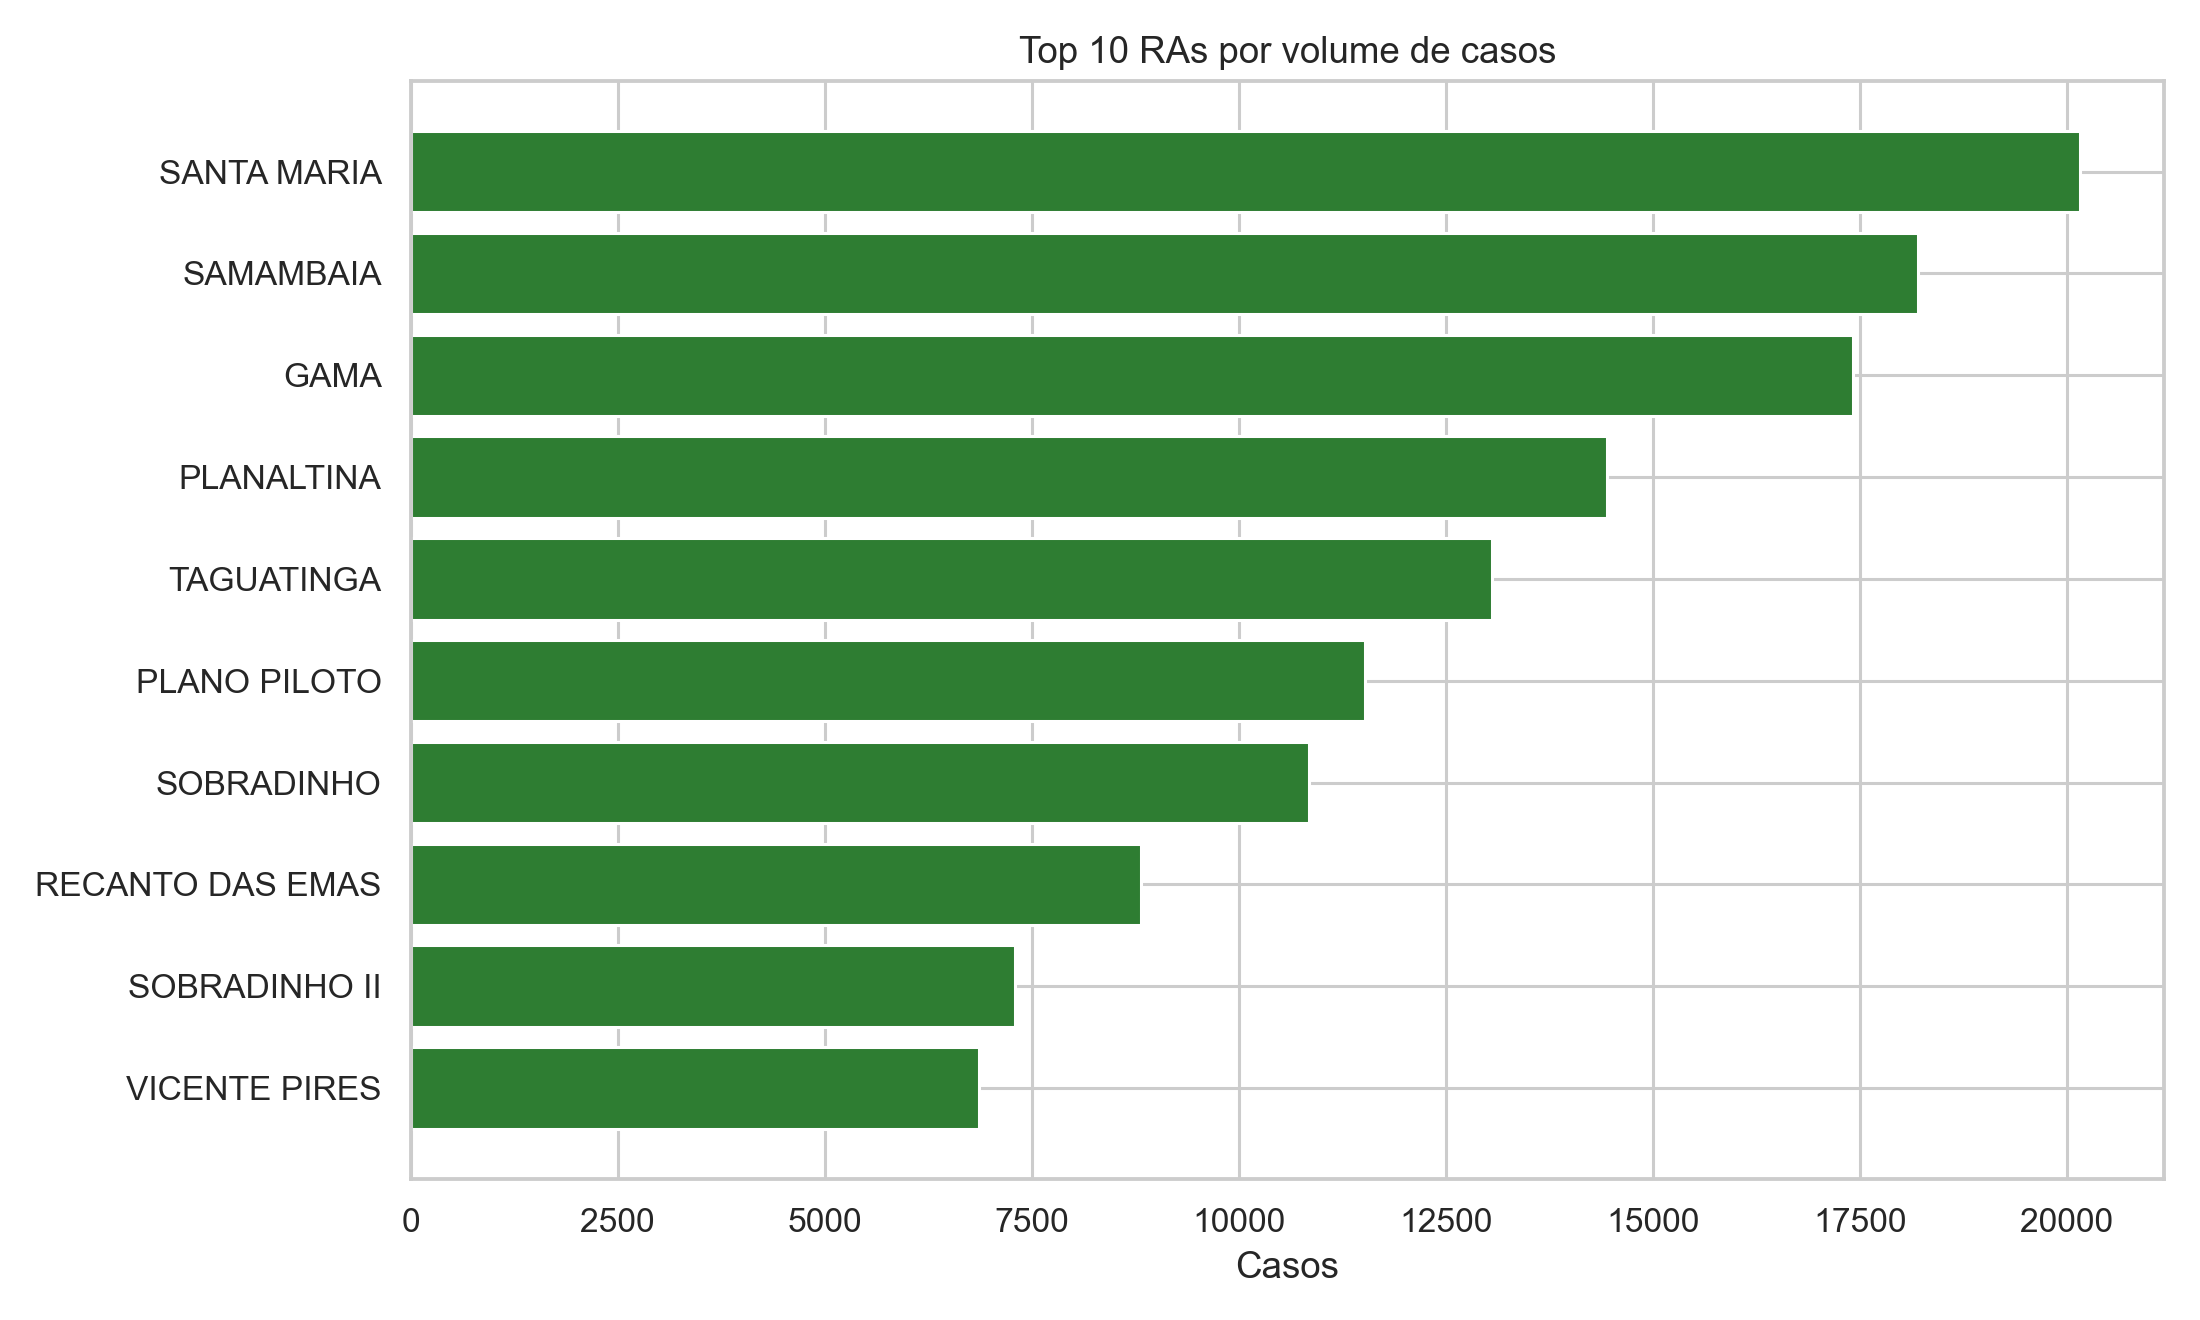

In [5]:

# CÉLULA 5: ANÁLISE EXPLORATÓRIA - SÉRIES TEMPORAIS
# ============================================================================
print("=" * 80)
print("PASSO 4: SÉRIES TEMPORAIS, OUTLIERS E COMPARAÇÕES ENTRE RAs")
print("=" * 80)

print("\n📊 1. Série Temporal Consolidada do Distrito Federal (Picos Epidemiológicos):")
print("-" * 80)
display(Image(filename='resultados_graficos/serie_df_total_qualidade.png'))

print("\n📊 2. Comparativo de Casos vs Incidência por 100k (Ceilândia vs Lago Sul):")
print("-" * 80)
display(Image(filename='resultados_graficos/populacao_cases_incidencia.png'))

print("\n📊 3. Top 10 Regiões Administrativas por Volume Total de Casos:")
print("-" * 80)
display(Image(filename='resultados_graficos/top10_ra_volume.png'))


# ==================================================================================
# CÉLULA 6: CORRELAÇÕES CLIMÁTICAS (SPEARMAN) E CALOR SEMANAL
# ==================================================================================


PASSO 5: SPEARMAN DOS LAGS CLIMÁTICOS E CALOR TEMPORAL POR RA

🔥 1. Heatmap Spearman: Correlação de Lags Climáticos vs Incidência de Dengue:
--------------------------------------------------------------------------------

🔥 2. Heatmap RA vs Semana Epidemiológica (Evolução da Transmissão):
--------------------------------------------------------------------------------


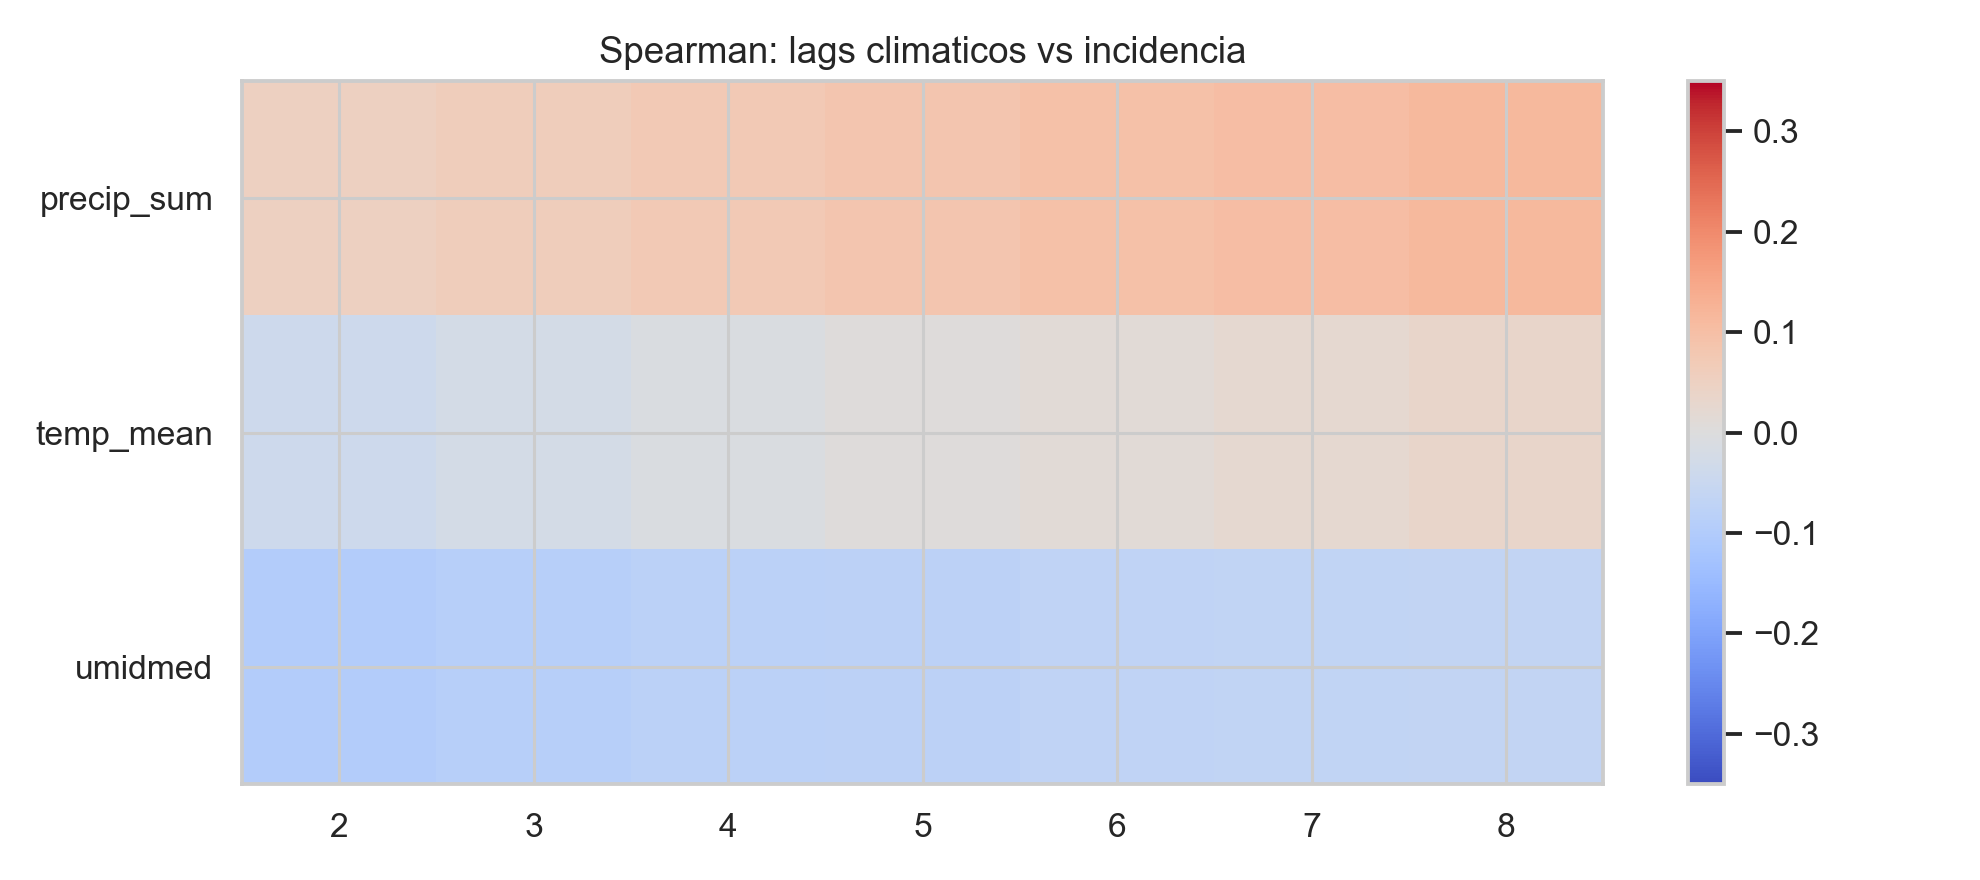

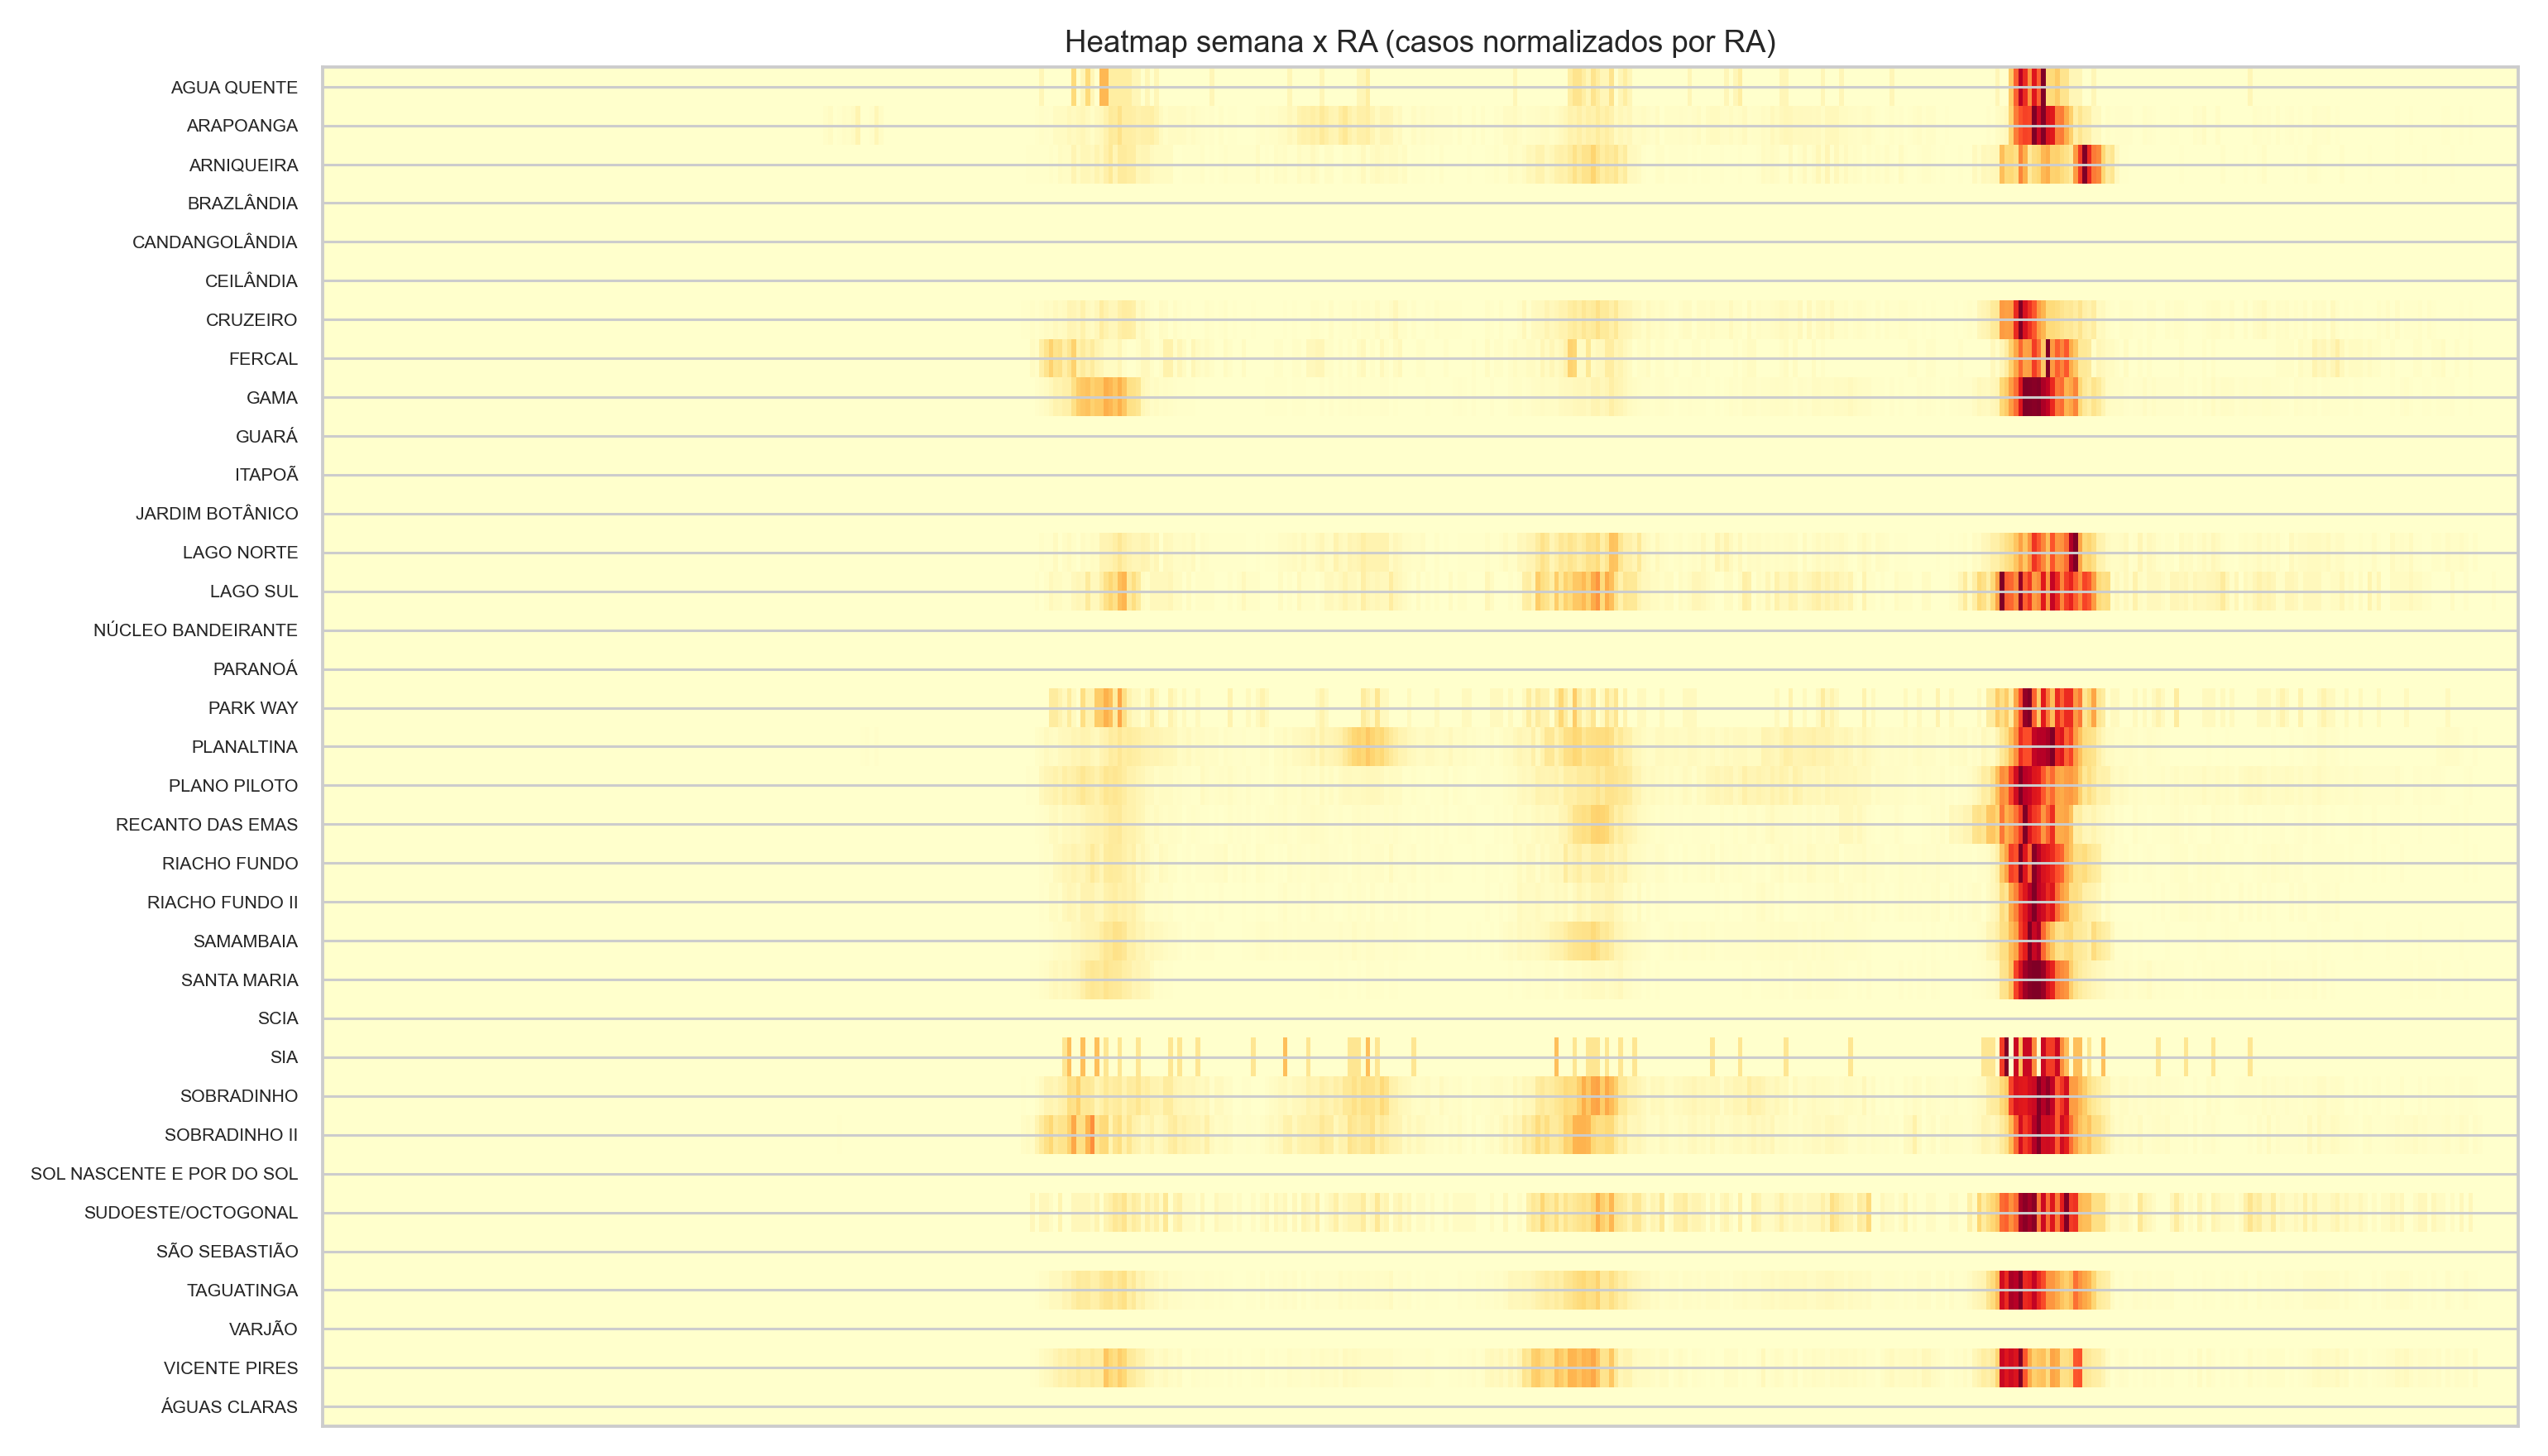

In [6]:

# CÉLULA 6: CORRELAÇÕES CLIMÁTICAS E CALOR SEMANAL
# ============================================================================
print("=" * 80)
print("PASSO 5: SPEARMAN DOS LAGS CLIMÁTICOS E CALOR TEMPORAL POR RA")
print("=" * 80)

print("\n🔥 1. Heatmap Spearman: Correlação de Lags Climáticos vs Incidência de Dengue:")
print("-" * 80)
display(Image(filename='resultados_graficos/correlacao_lags_clima.png'))

print("\n🔥 2. Heatmap RA vs Semana Epidemiológica (Evolução da Transmissão):")
print("-" * 80)
display(Image(filename='resultados_graficos/heatmap_ra_semana.png'))


# ==================================================================================
# CÉLULA 7: VALIDAÇÃO EM JANELA MÓVEL (ROLLING VALIDATION OPERACIONAL)
# ==================================================================================


In [7]:

# CÉLULA 7: VALIDAÇÃO EM JANELA MÓVEL (ROLLING NOWCASTING)
# ============================================================================
print("=" * 80)
print("PASSO 6: VALIDAÇÃO EM JANELA MÓVEL (ROLLING NOWCASTING SEM LEAKAGE)")
print("=" * 80)

rolling_res = p.run_rolling_validation(dataset)

print("\n[MÉTRICAS DE PERFORMANCE DA VALIDAÇÃO EM JANELA MÓVEL]")
print("-" * 80)
display(rolling_res)


PASSO 6: VALIDAÇÃO EM JANELA MÓVEL (ROLLING NOWCASTING SEM LEAKAGE)
>>> P1: executando rolling validation nowcasting vs forecast fechado...

[MÉTRICAS DE PERFORMANCE DA VALIDAÇÃO EM JANELA MÓVEL]
--------------------------------------------------------------------------------


,modo,r2_df,mae_df,rmse_df,r2_media_ras,mae_media_ras,rmse_media_ras
0,nowcasting_rolling,0.656166,11.039531,13.819021,-0.002730,0.866251,1.134339
1,forecast_fechado_recursivo,-0.280879,23.331291,26.672077,-0.339635,1.046472,1.383608


# ==================================================================================
# CÉLULA 8: ANÁLISE DE ABLAÇÃO DE FEATURES (TESTE DE HIPÓTESES DE GANHO MARGINAL)
# ==================================================================================


PASSO 7: ANÁLISE DE ABLAÇÃO E CONTRIBUIÇÃO DE FEATURES
>>> P1: executando ablation tests...
  - lag-only / RF
  - lag-only / XGB
  - lag+clima / RF
  - lag+clima / XGB
  - lag+clima+RA / RF
  - lag+clima+RA / XGB
  - lag+clima+RA+incid-target / RF
  - lag+clima+RA+incid-target / XGB

[RESULTADOS COMPARATIVOS DOS TESTES DE ABLAÇÃO]
--------------------------------------------------------------------------------

[CONFIGURAÇÃO VENCEDORA (CRITÉRIO CONSERVADOR DELTA R² > 0.05)]
--------------------------------------------------------------------------------
  • config: lag+clima+RA
  • modelo: RF
  • r2_df: 0.6561657429237491
  • rmse_df: 13.819021055339869
  • accepted_complex_gain: True
  • best_observed_config: lag+clima+RA
  • best_observed_modelo: RF
  • best_delta_r2_vs_baseline: 0.0007025049712388043
  • best_rmse_improved_pct_vs_baseline: 0.8
  • reason: Melhor config superou o baseline pelo criterio de aceite.

📊 1. Comparativo R² (DF) por Configuração de Features:
---------------

,config,modelo,n_features,r2_df,mae_df,rmse_df,r2_media_ras,mae_media_ras,rmse_media_ras,delta_r2_df_vs_prev,rmse_improved_pct_vs_prev,passes_acceptance_vs_prev
0,lag-only,RF,4,0.655463,10.468871,13.833131,-0.111227,0.919626,1.209586,NaN,NaN,False
1,lag-only,XGB,4,0.609037,11.579937,14.735684,0.065103,0.839568,1.109043,NaN,NaN,False
2,lag+clima,RF,29,0.648325,11.047745,13.975703,-0.007130,0.868230,1.149014,-0.007139,0.428571,False
3,lag+clima,XGB,29,0.600697,11.535270,14.892039,0.031588,0.866360,1.141038,-0.008341,0.171429,False
4,lag+clima+RA,RF,64,0.656166,11.039531,13.819021,-0.002730,0.866251,1.134339,0.007841,0.742857,True
5,lag+clima+RA,XGB,64,0.574179,11.845747,15.378580,0.027844,0.871257,1.151828,-0.026518,0.685714,False
6,lag+clima+RA+incid-target,RF,65,0.572377,12.137029,15.411085,0.031153,0.881082,1.130958,-0.083789,0.600000,False
7,lag+clima+RA+incid-target,XGB,65,0.554013,11.617192,15.738519,0.032498,0.889346,1.154552,-0.020166,0.485714,False


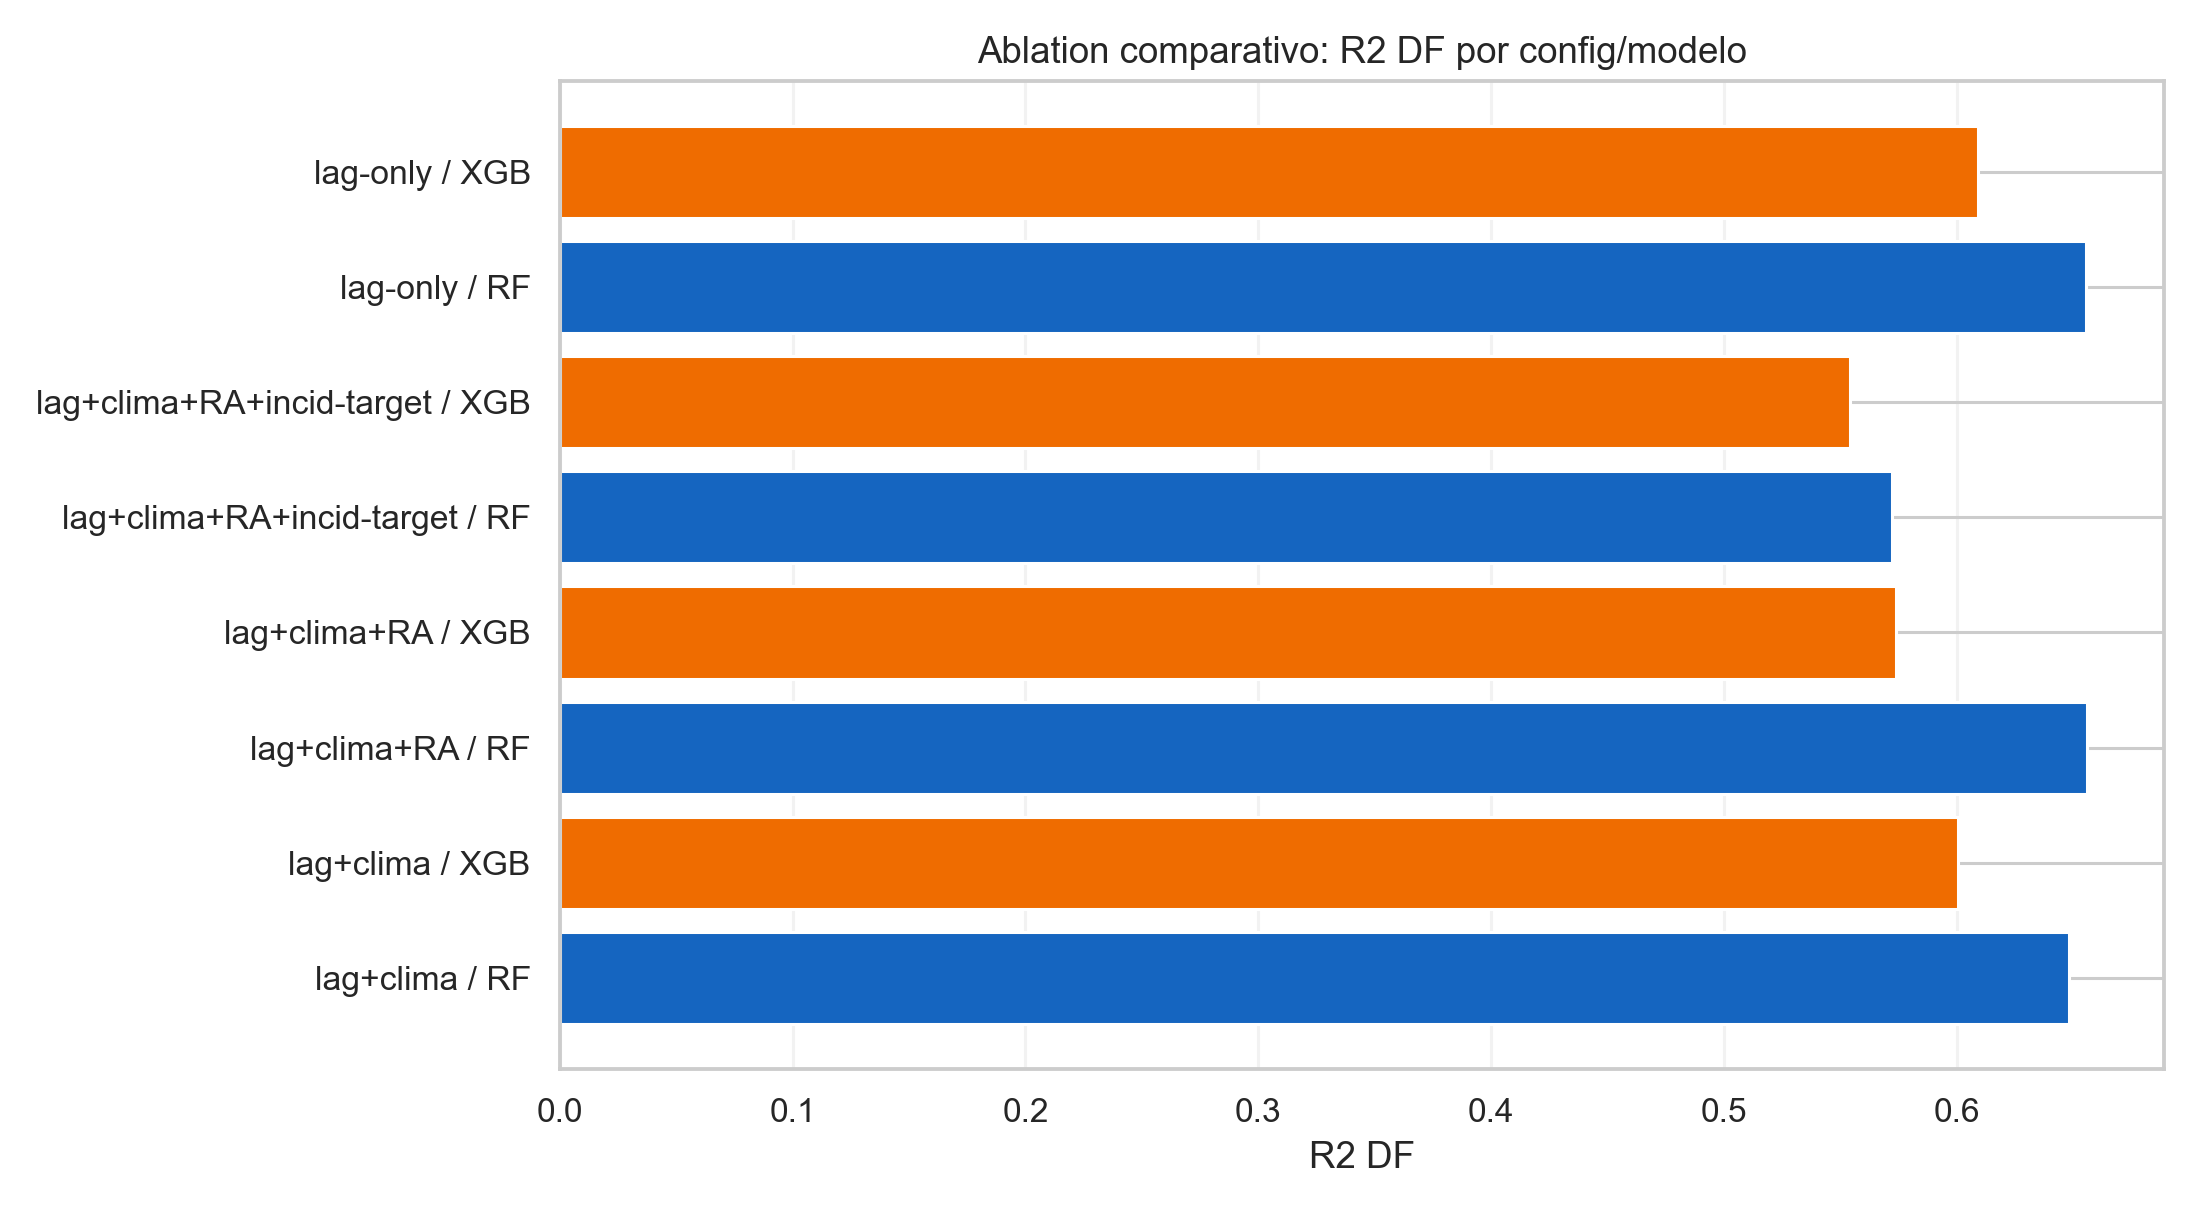

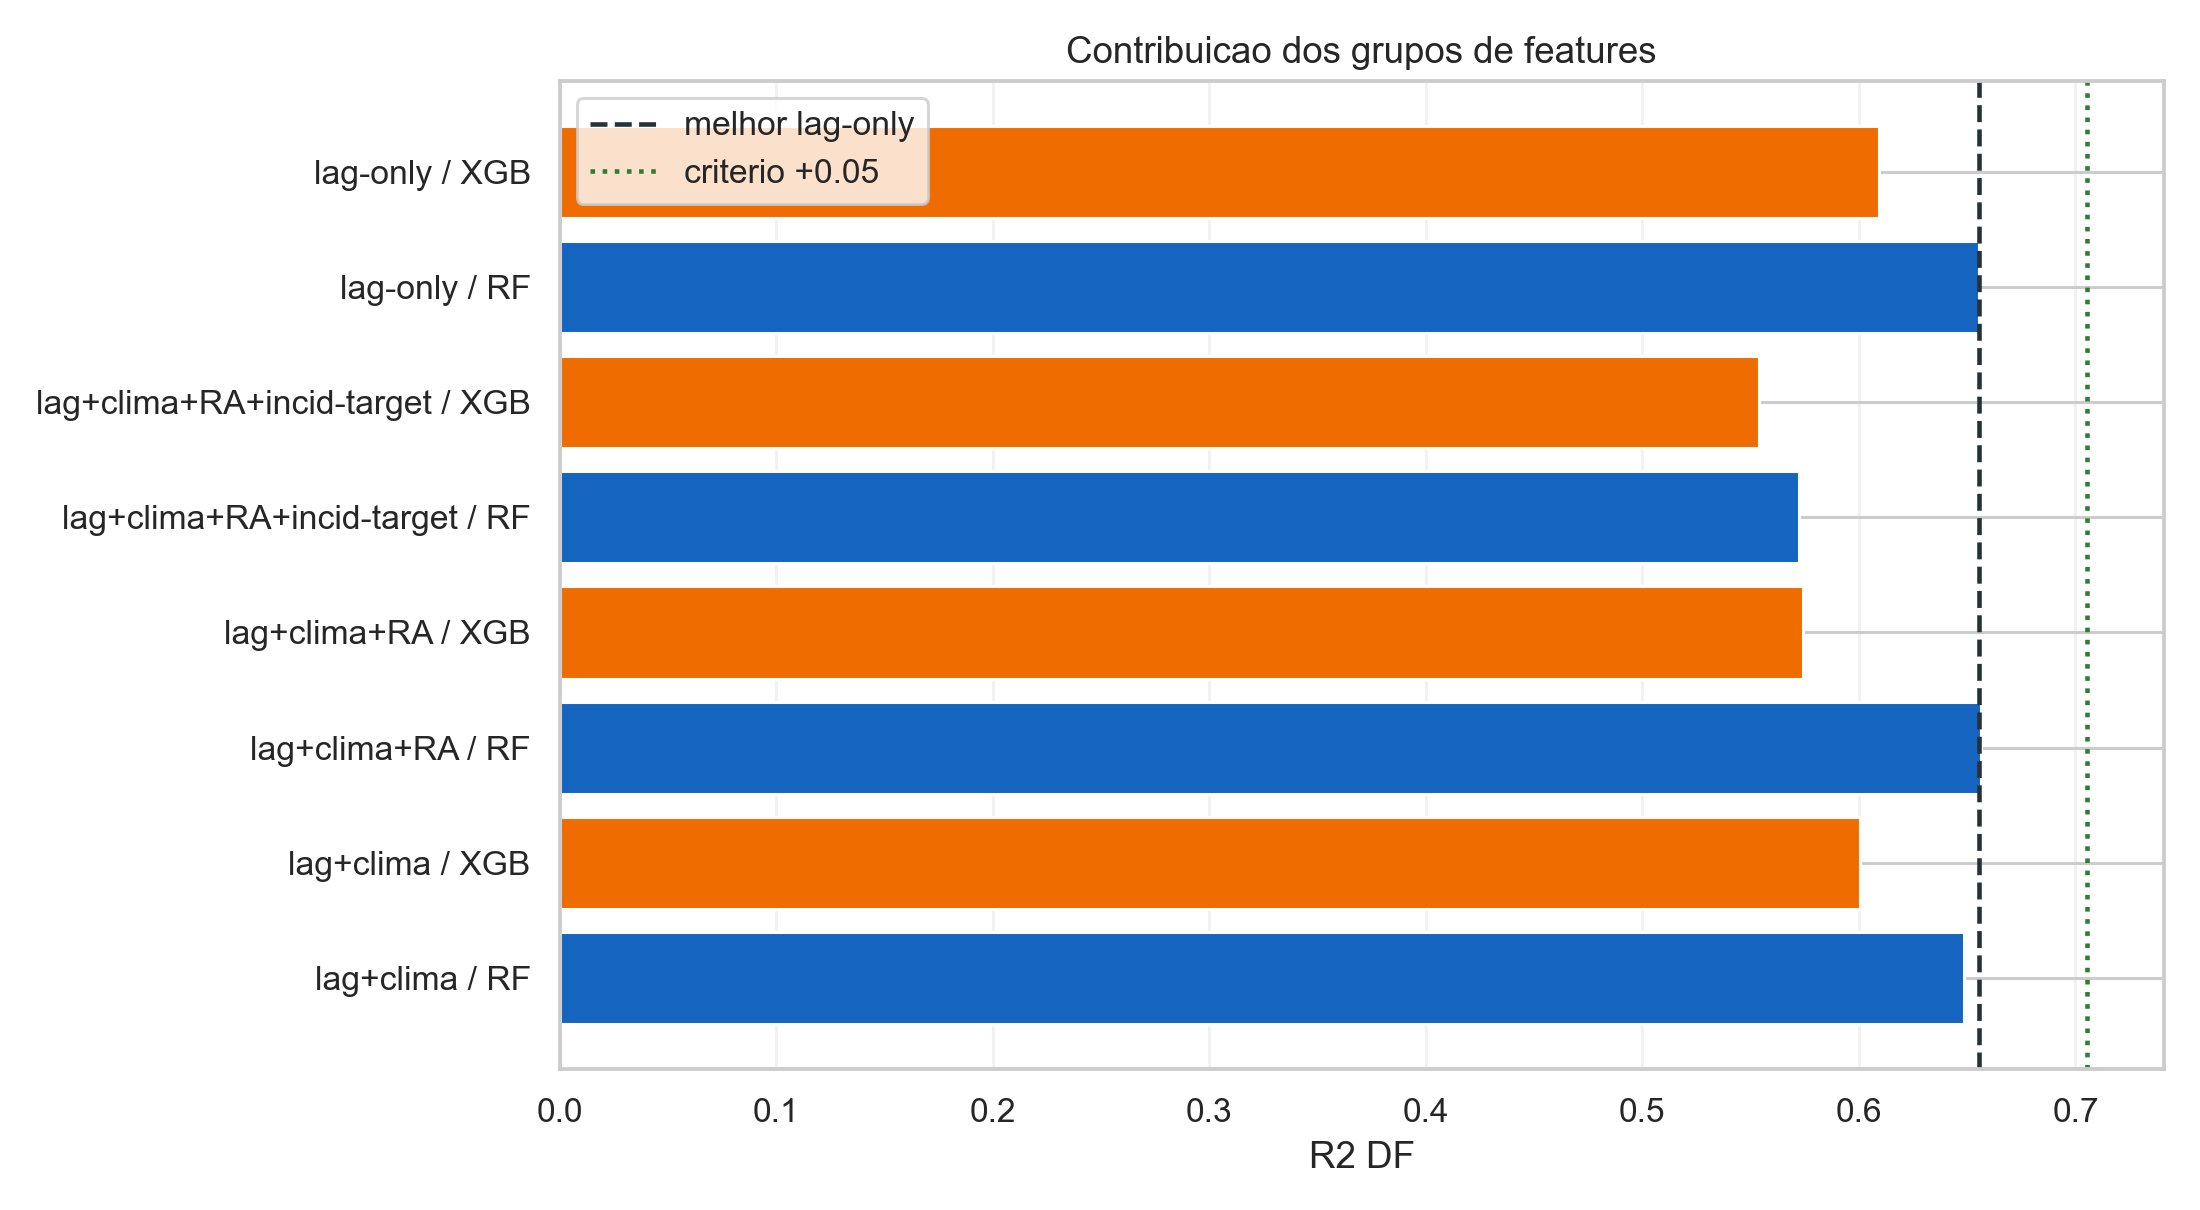

In [8]:

# CÉLULA 8: ANÁLISE DE ABLAÇÃO DE FEATURES
# ============================================================================
print("=" * 80)
print("PASSO 7: ANÁLISE DE ABLAÇÃO E CONTRIBUIÇÃO DE FEATURES")
print("=" * 80)

ablation_res, winner_config = p.run_ablation_tests(dataset)

print("\n[RESULTADOS COMPARATIVOS DOS TESTES DE ABLAÇÃO]")
print("-" * 80)
display(ablation_res)

print("\n[CONFIGURAÇÃO VENCEDORA (CRITÉRIO CONSERVADOR DELTA R² > 0.05)]")
print("-" * 80)
for k, v in winner_config.items():
    print(f"  • {k}: {v}")

print("\n📊 1. Comparativo R² (DF) por Configuração de Features:")
print("-" * 80)
display(Image(filename='resultados_graficos/ablation_comparativo.png'))

print("\n📊 2. Análise de Contribuição Marginal (vs Melhor Lag-Only):")
print("-" * 80)
display(Image(filename='resultados_graficos/ablation_contribuicao.png'))


# ==================================================================================
# CÉLULA 9: TUNING E OTIMIZAÇÃO DE MODELOS (RF E XGBOOST)
# ==================================================================================


In [9]:

# CÉLULA 9: TUNING E OTIMIZAÇÃO DOS MODELOS
# ============================================================================
print("=" * 80)
print("PASSO 8: OTIMIZAÇÃO DE HIPERPARÂMETROS DA CONFIGURAÇÃO VENCEDORA")
print("=" * 80)

tuning_res, final_predictions = p.tune_models(dataset, winner_config['config'])

print("\n[RESULTADOS DO TUNING DE PARÂMETROS]")
print("-" * 80)
display(tuning_res)


PASSO 8: OTIMIZAÇÃO DE HIPERPARÂMETROS DA CONFIGURAÇÃO VENCEDORA
>>> P1: tuning RF e XGBoost na config lag+clima+RA...
  - RF grid 1/36
  - RF grid 2/36
  - RF grid 3/36
  - RF grid 4/36
  - RF grid 5/36
  - RF grid 6/36
  - RF grid 7/36
  - RF grid 8/36
  - RF grid 9/36
  - RF grid 10/36
  - RF grid 11/36
  - RF grid 12/36
  - RF grid 13/36
  - RF grid 14/36
  - RF grid 15/36
  - RF grid 16/36
  - RF grid 17/36
  - RF grid 18/36
  - RF grid 19/36
  - RF grid 20/36
  - RF grid 21/36
  - RF grid 22/36
  - RF grid 23/36
  - RF grid 24/36
  - RF grid 25/36
  - RF grid 26/36
  - RF grid 27/36
  - RF grid 28/36
  - RF grid 29/36
  - RF grid 30/36
  - RF grid 31/36
  - RF grid 32/36
  - RF grid 33/36
  - RF grid 34/36
  - RF grid 35/36
  - RF grid 36/36
  - XGB grid 1/72
  - XGB grid 2/72
  - XGB grid 3/72
  - XGB grid 4/72
  - XGB grid 5/72
  - XGB grid 6/72
  - XGB grid 7/72
  - XGB grid 8/72
  - XGB grid 9/72
  - XGB grid 10/72
  - XGB grid 11/72
  - XGB grid 12/72
  - XGB grid 13/72
  - 

,modelo,config,cv_rmse,params
25,RF,lag+clima+RA,30.143217,"{""max_depth"": null, ""max_features"": ""sqrt"", ""m..."
24,RF,lag+clima+RA,30.220190,"{""max_depth"": null, ""max_features"": ""sqrt"", ""m..."
13,RF,lag+clima+RA,31.049452,"{""max_depth"": 10, ""max_features"": ""sqrt"", ""min..."
12,RF,lag+clima+RA,31.269206,"{""max_depth"": 10, ""max_features"": ""sqrt"", ""min..."
27,RF,lag+clima+RA,31.369565,"{""max_depth"": null, ""max_features"": ""sqrt"", ""m..."
...,...,...,...,...
80,XGB,lag+clima+RA,32.080285,"{""colsample_bytree"": 1.0, ""learning_rate"": 0.0..."
37,XGB,lag+clima+RA,32.928669,"{""colsample_bytree"": 0.8, ""learning_rate"": 0.0..."
72,XGB,lag+clima+RA,32.934092,"{""colsample_bytree"": 1.0, ""learning_rate"": 0.0..."
73,XGB,lag+clima+RA,32.971865,"{""colsample_bytree"": 1.0, ""learning_rate"": 0.0..."


# ==================================================================================
# CÉLULA 10: IMPORTÂNCIA DE FEATURES E PREVISÕES FINAIS VS REALIDADE
# ==================================================================================


PASSO 9: IMPORTÂNCIA DE FEATURES E PERFORMANCE VISUAL FINAL

📊 1. Importância de Features (Modelo XGBoost):
--------------------------------------------------------------------------------

📊 2. Previsão Final vs Casos Reais (Distrito Federal Total):
--------------------------------------------------------------------------------

📊 3. Séries Temporais Detalhadas das Top 6 RAs com R² individual:
--------------------------------------------------------------------------------

📊 4. Incidência Média por Região Administrativa em 2025:
--------------------------------------------------------------------------------


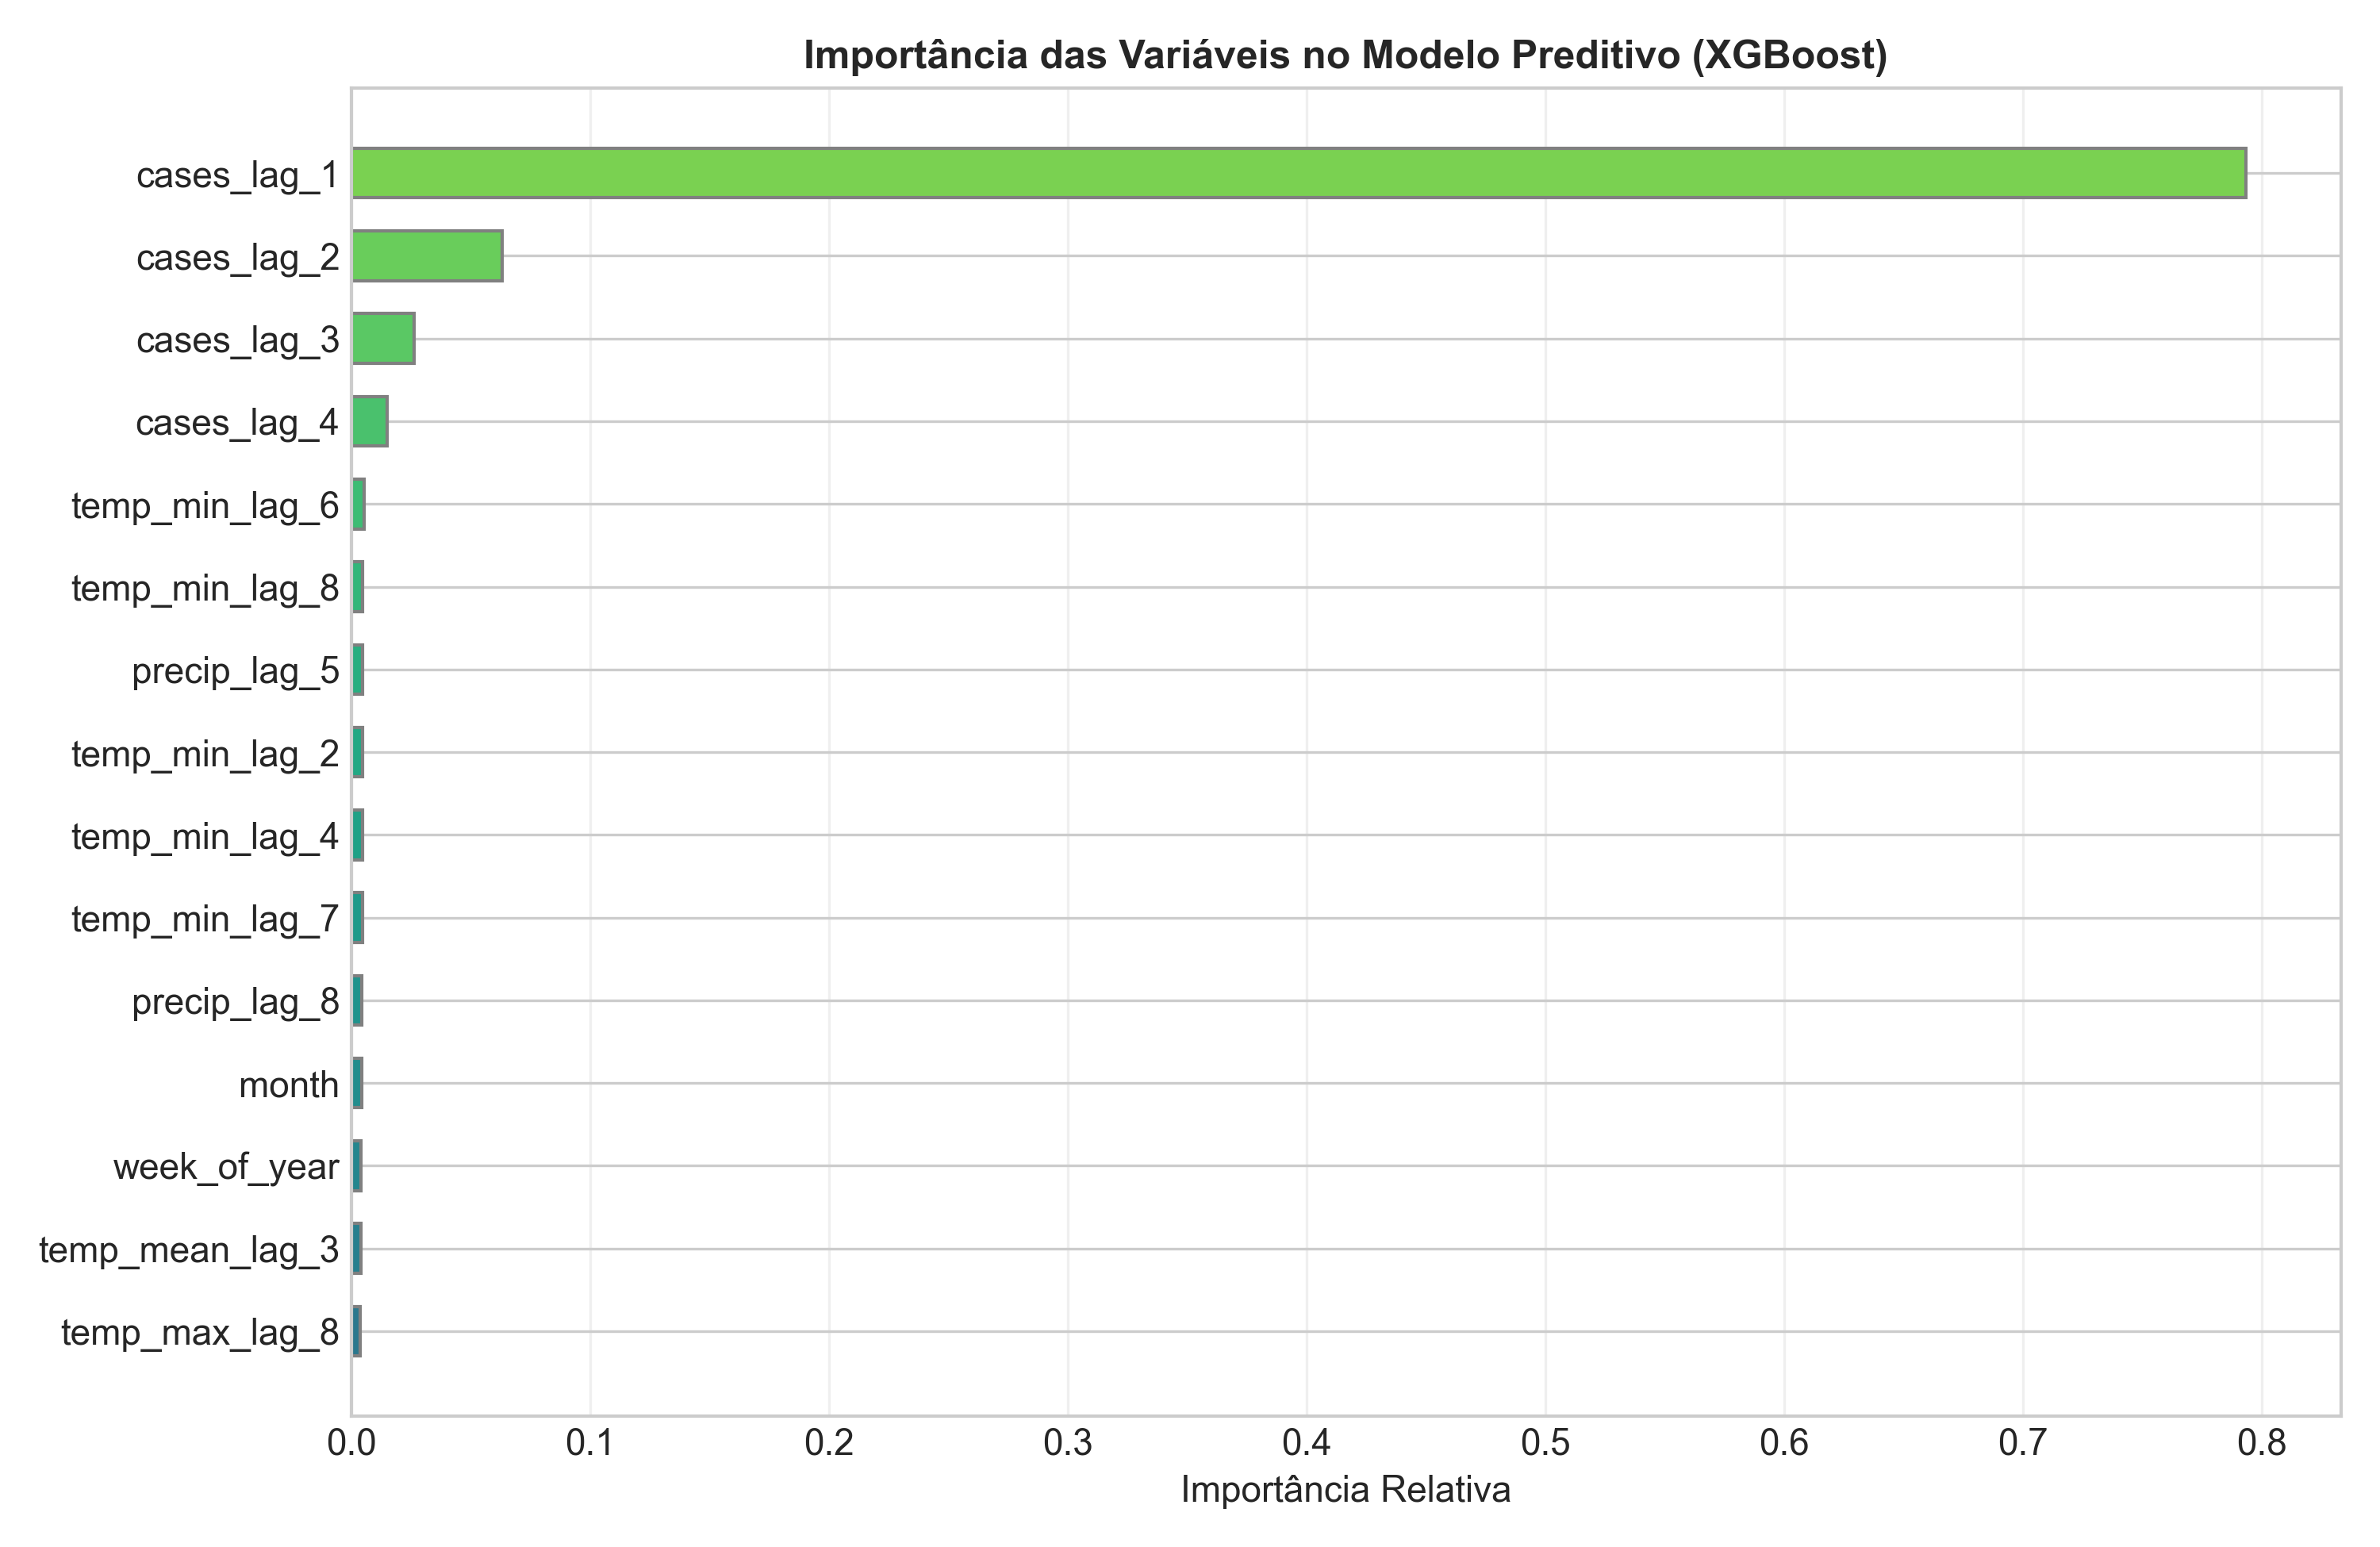

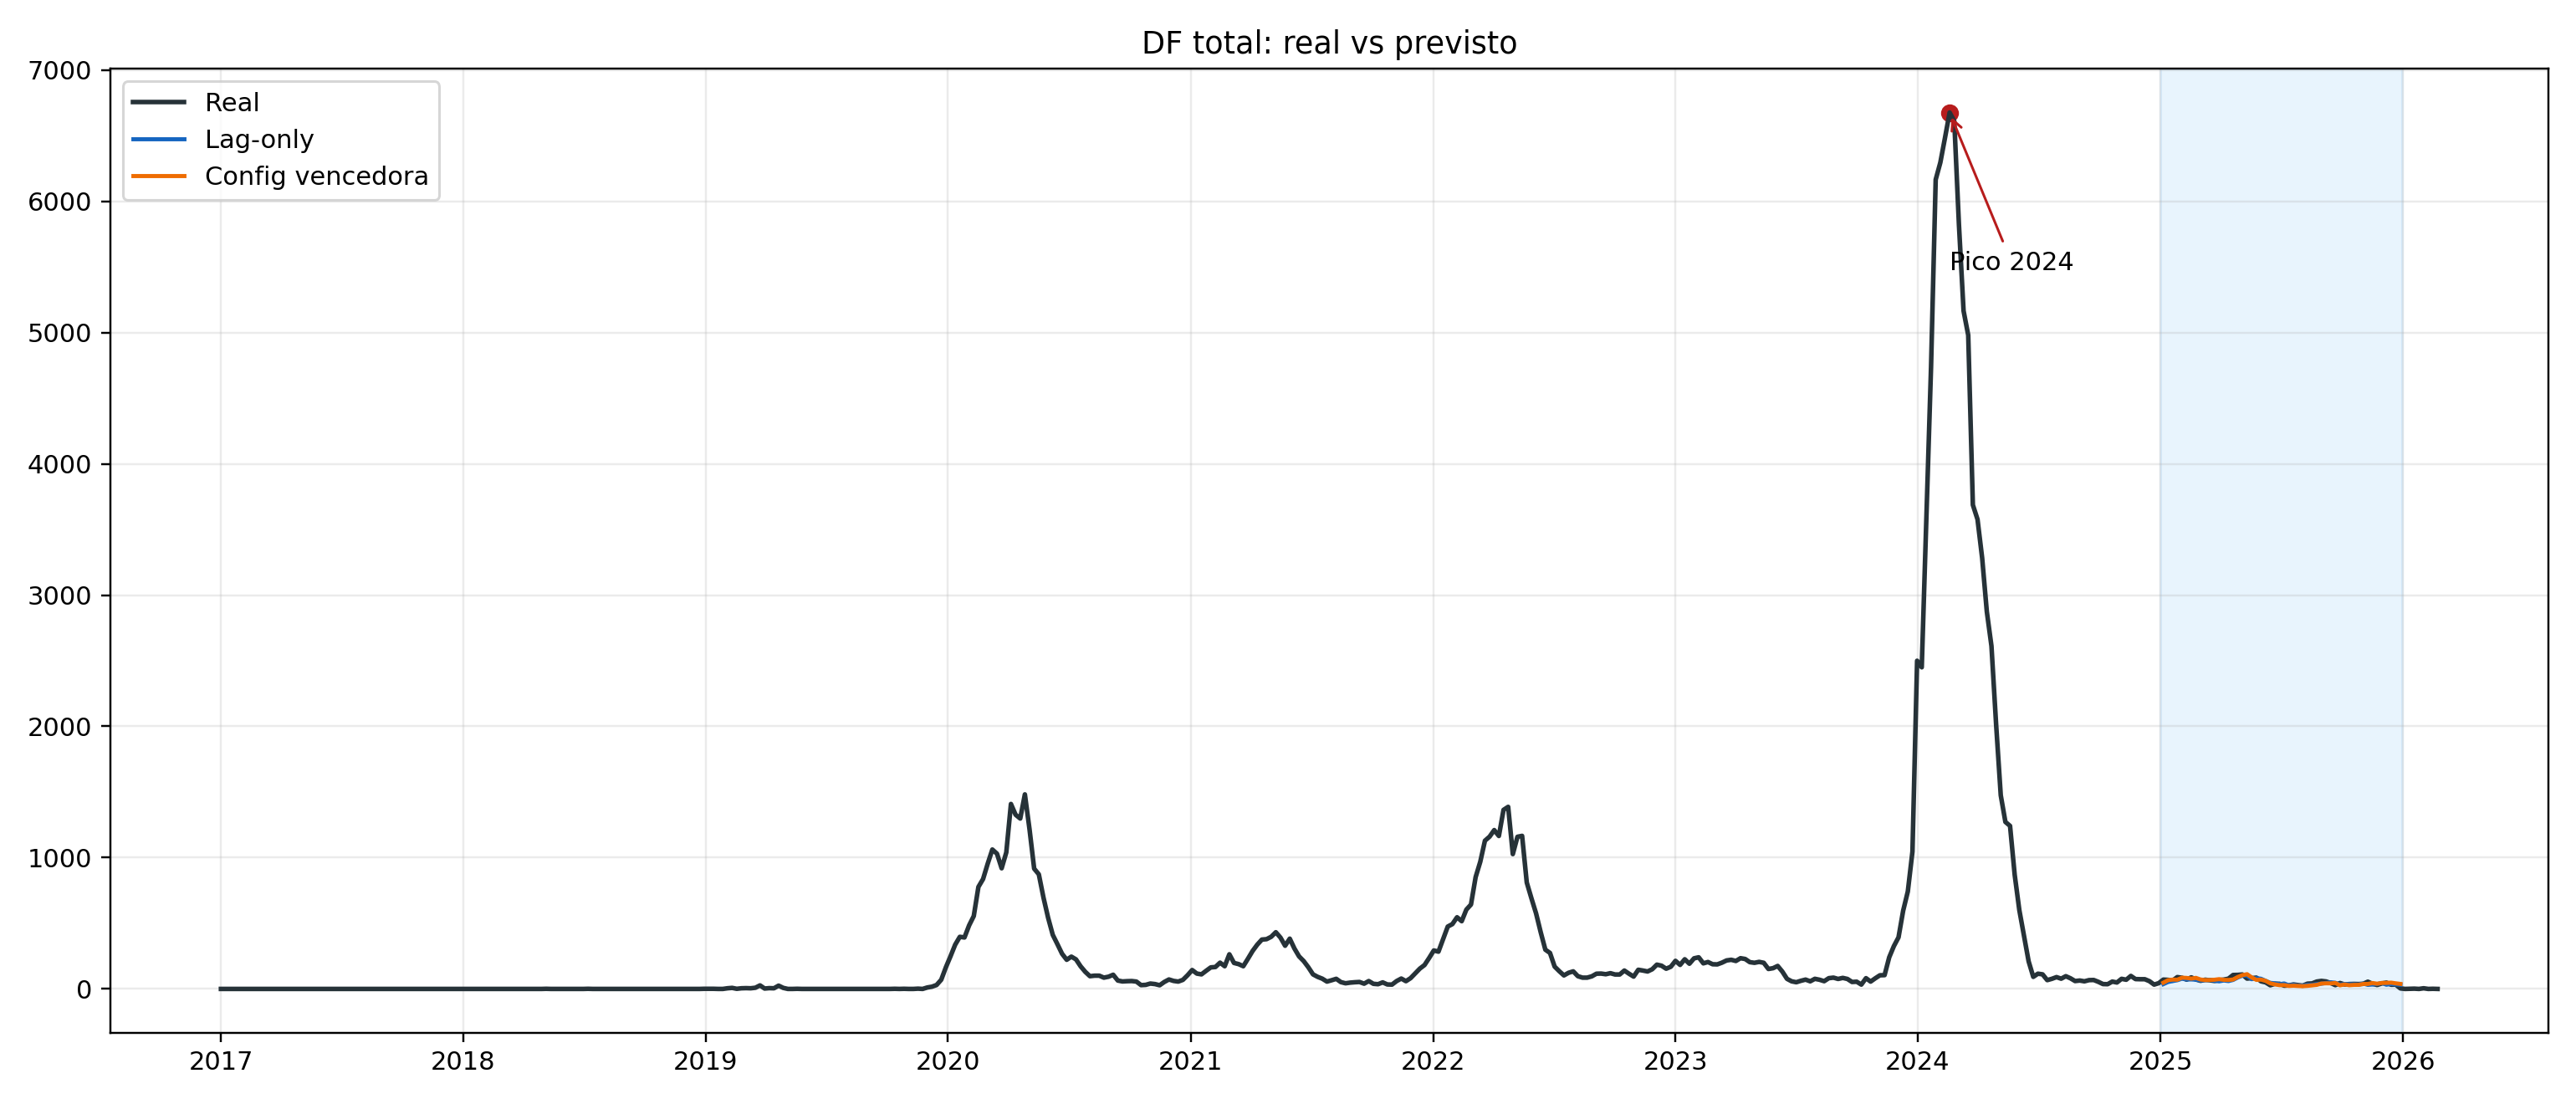

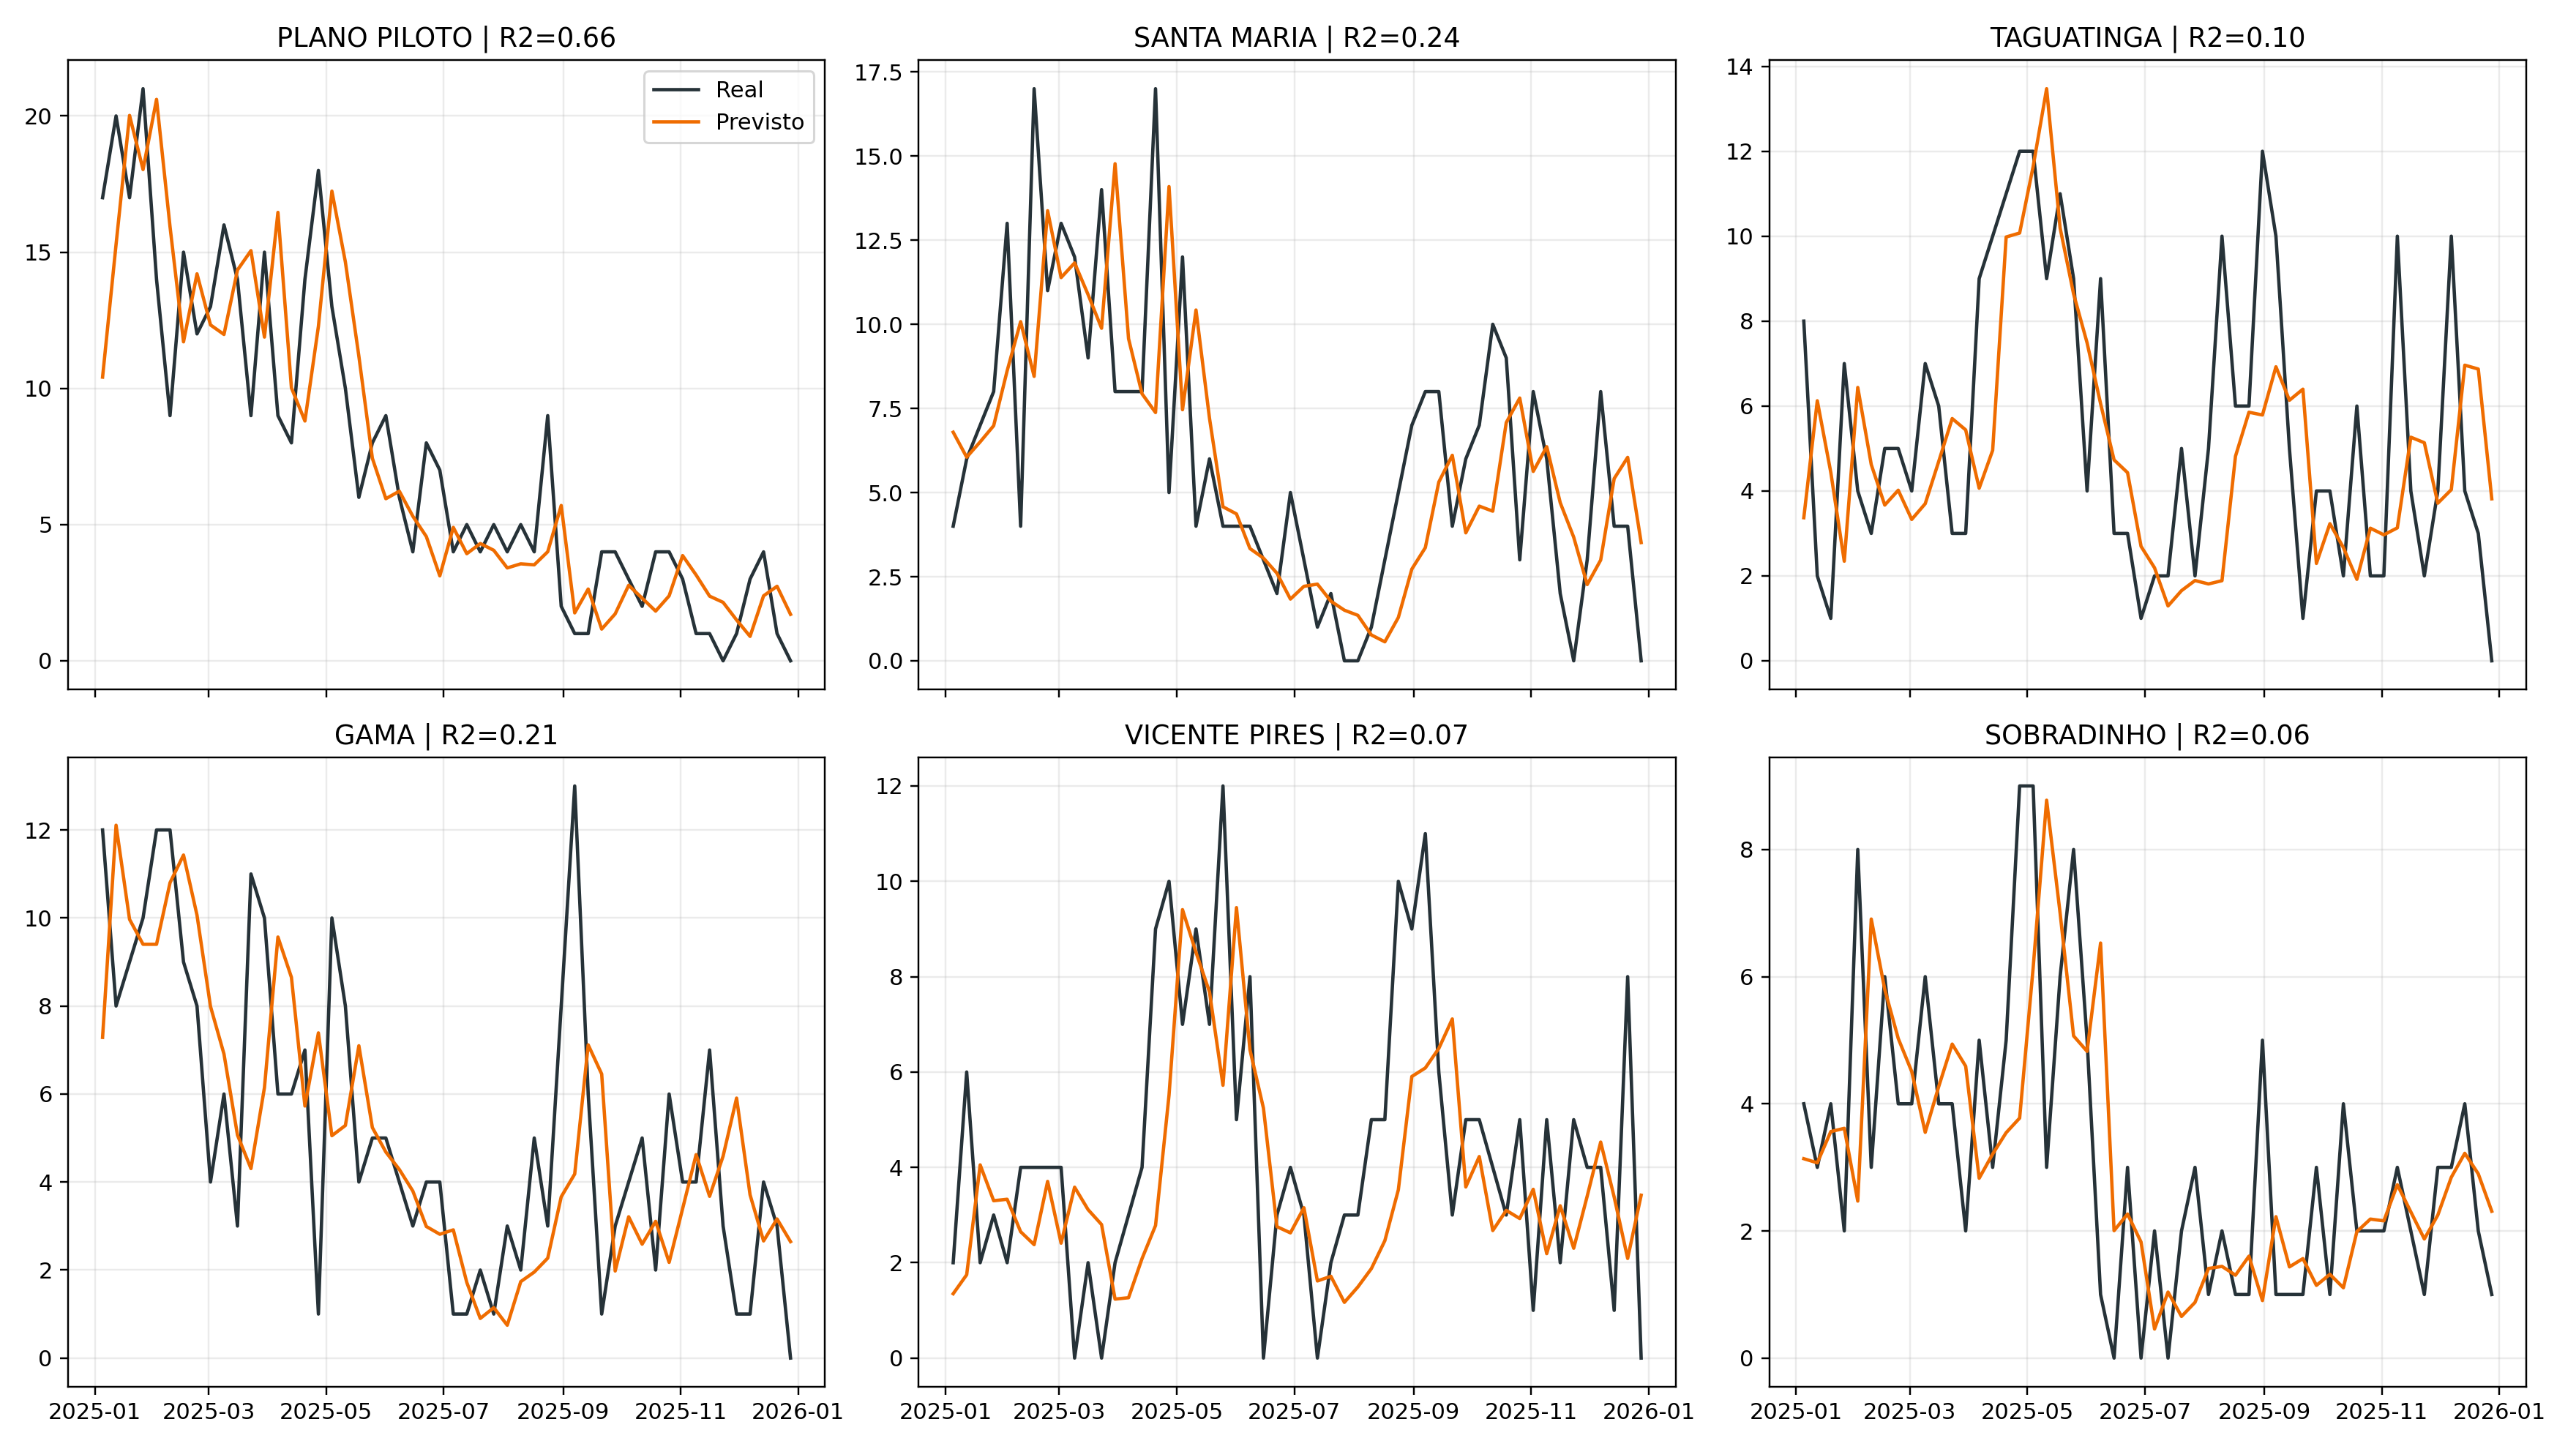

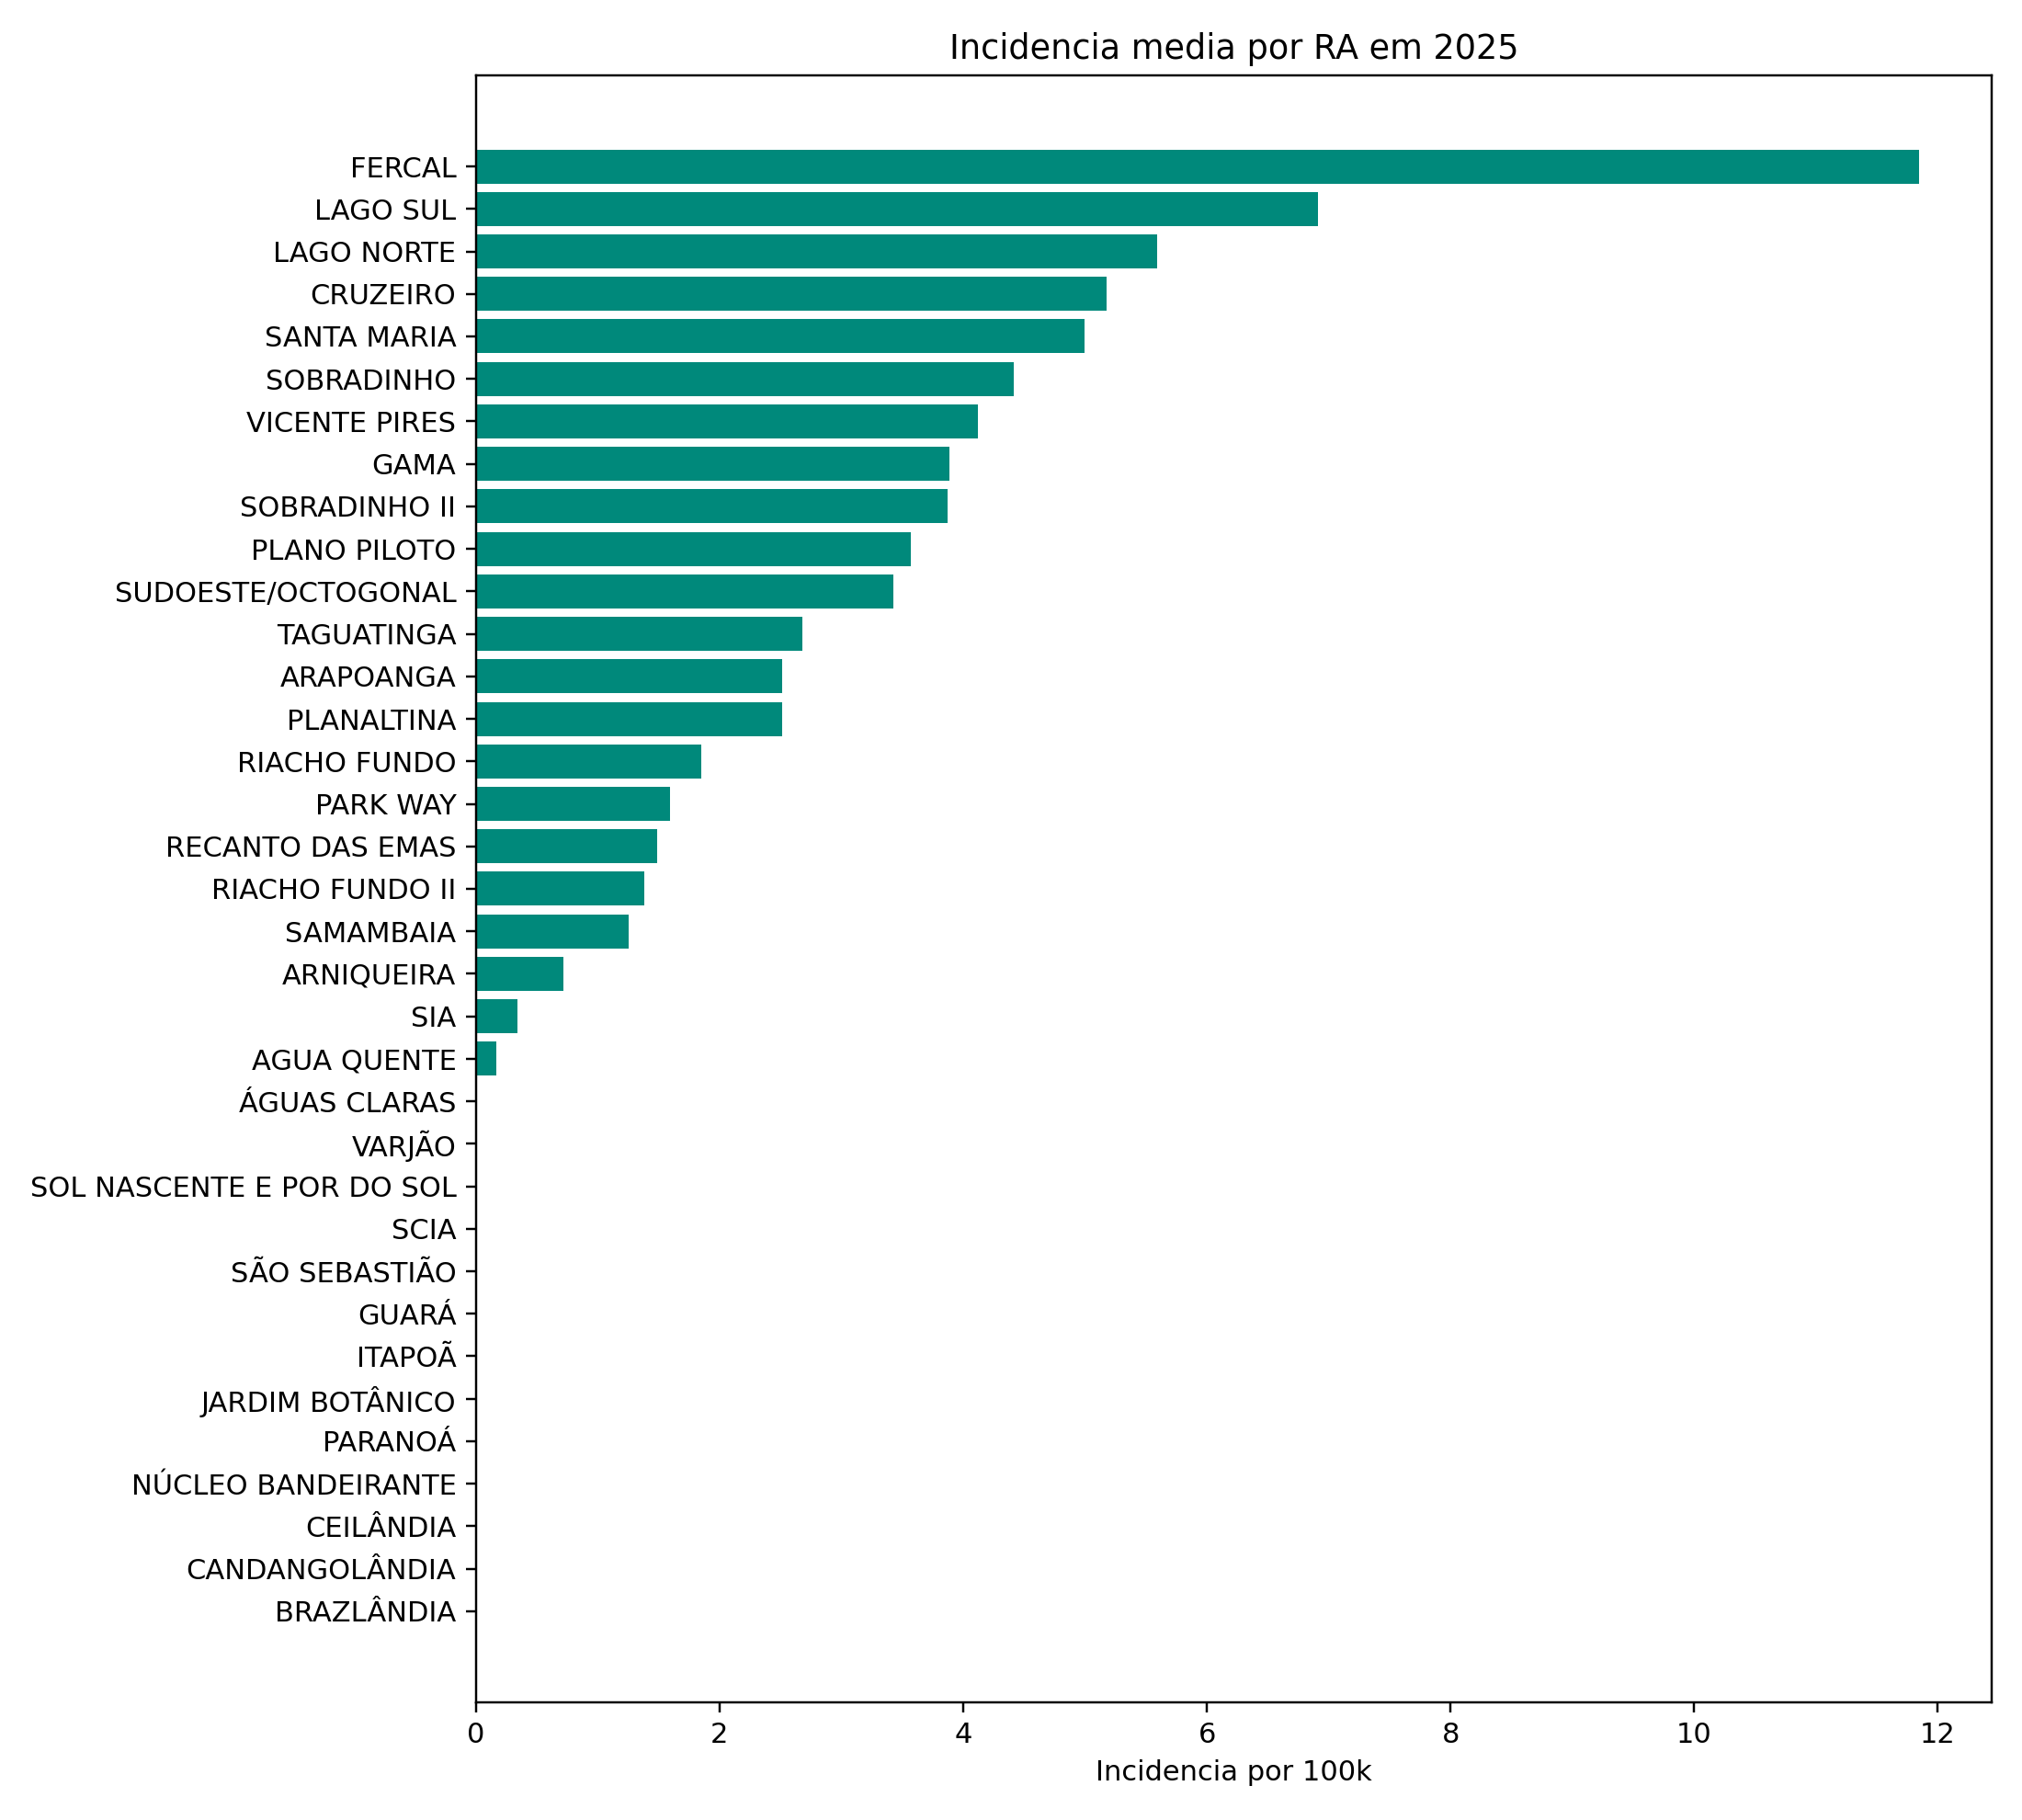

In [10]:

# CÉLULA 10: IMPORTÂNCIA DE FEATURES E PREVISÕES FINAIS
# ============================================================================
print("=" * 80)
print("PASSO 9: IMPORTÂNCIA DE FEATURES E PERFORMANCE VISUAL FINAL")
print("=" * 80)

print("\n📊 1. Importância de Features (Modelo XGBoost):")
print("-" * 80)
display(Image(filename='resultados_graficos/importancia_features_xgb.png'))

print("\n📊 2. Previsão Final vs Casos Reais (Distrito Federal Total):")
print("-" * 80)
display(Image(filename='resultados_graficos/serie_df_total.png'))

print("\n📊 3. Séries Temporais Detalhadas das Top 6 RAs com R² individual:")
print("-" * 80)
display(Image(filename='resultados_graficos/series_top6_ra.png'))

print("\n📊 4. Incidência Média por Região Administrativa em 2025:")
print("-" * 80)
display(Image(filename='resultados_graficos/incidencia_por_ra_2025.png'))


# ==================================================================================
# CÉLULA 11: VALIDAÇÃO FEDERAL (SINAN 2017 VS INFO-SAÚDE 2017)
# ==================================================================================


PASSO 10: ALINHAMENTO HISTÓRICO SINAN vs INFO-SAÚDE (2017)
>>> P2: validando SINAN 2017 vs info-saude 2017...

[MÉTRICAS DE ALINHAMENTO EPIDEMIOLÓGICO]
--------------------------------------------------------------------------------
  • residencia: {'corr': 0.9979149404526364, 'mean_pct': 6.729112791306174, 'max_pct': 300.0, 'accepted': True}
  • notificacao: {'corr': 0.9940067674171208, 'mean_pct': 20.396042866207072, 'max_pct': 300.0, 'accepted': False}
  • accepted: True

📊 Gráfico de Compatibilidade e Diferença Percentual Absoluta (Critério 15%):
--------------------------------------------------------------------------------


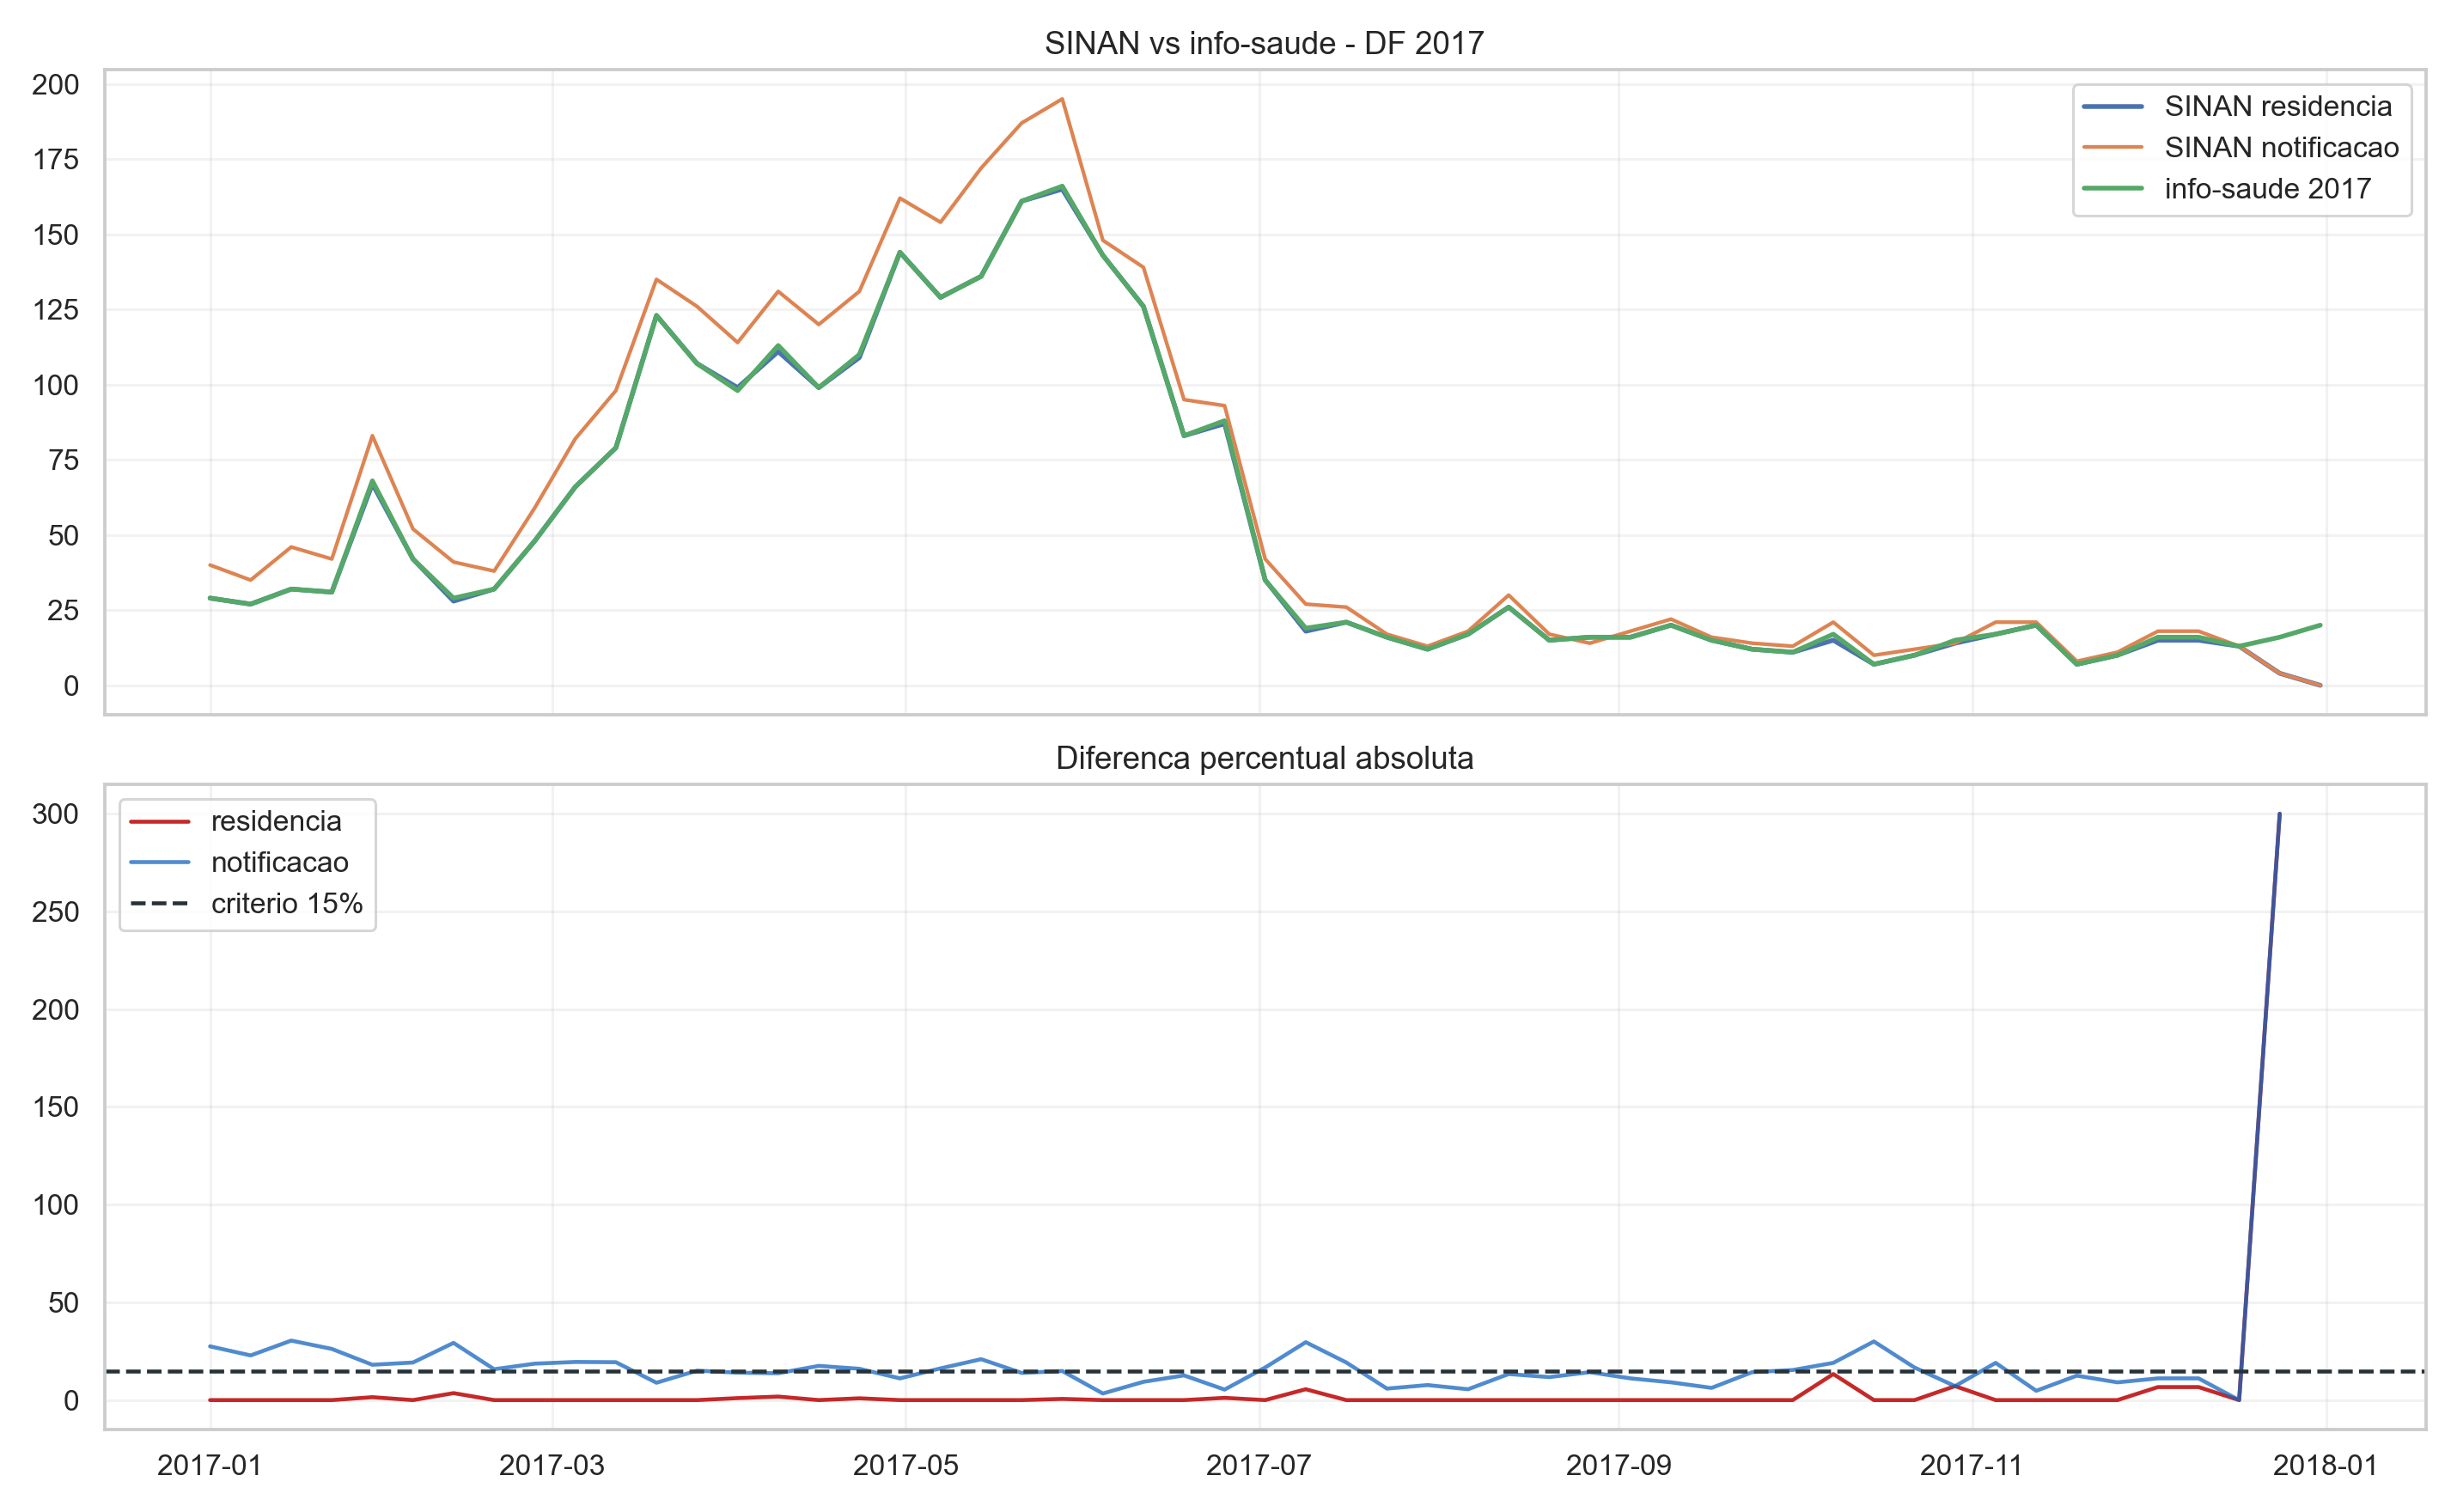

In [11]:

# CÉLULA 11: VALIDAÇÃO FEDERAL (SINAN VS INFO-SAÚDE)
# ============================================================================
print("=" * 80)
print("PASSO 10: ALINHAMENTO HISTÓRICO SINAN vs INFO-SAÚDE (2017)")
print("=" * 80)

sinan_res = p.validate_sinan_infosaude(target_decision['target_name'])

print("\n[MÉTRICAS DE ALINHAMENTO EPIDEMIOLÓGICO]")
print("-" * 80)
for k, v in sinan_res.items():
    if k != 'selected_codes':
        print(f"  • {k}: {v}")

print("\n📊 Gráfico de Compatibilidade e Diferença Percentual Absoluta (Critério 15%):")
print("-" * 80)
display(Image(filename='resultados_graficos/sinan_infosaude_2017.png'))


# ==================================================================================
# CÉLULA 12: RESUMO EXECUTIVO E RELATÓRIO DO PIPELINE
# ==================================================================================


In [12]:

# CÉLULA 12: RESUMO EXECUTIVO E RELATÓRIO FINAL
# ============================================================================
print("=" * 80)
print("PASSO 11: RESUMO EXECUTIVO DO RELATÓRIO FINAL")
print("=" * 80)

report_text = Path(p.FINAL_REPORT_MD).read_text(encoding='utf-8')
print(report_text)


PASSO 11: RESUMO EXECUTIVO DO RELATÓRIO FINAL
# Relatorio final - Plano Prompts Opus

## Decisao de features

- Config vencedora conservadora: `lag+clima+RA` / `RF`.
- Melhor config observada: `lag+clima+RA` / `RF`.
- Ganho complexo aceito pelo criterio? `True`.
- Motivo: Melhor config superou o baseline pelo criterio de aceite.

## Respostas do Prompt 6

1. A config que agregou valor real demonstravel foi considerada apenas se superou lag-only por delta R2 > 0.05 ou RMSE melhor em >70% das RAs.
2. Resultado: Melhor config superou o baseline pelo criterio de aceite.
3. RA com maior RMSE na config vencedora: `SANTA MARIA` (RMSE=3.621). Hipotese: RAs com picos localizados e baixa base semanal sao mais dificeis para modelos globais.
4. O pipeline fica mais defensavel para nowcasting operacional semanal. Para forecast fechado, use o resultado recursivo como referencia; a incerteza cresce rapidamente sem casos reais recentes.
5. Antes da hierarquia nacional, a compatibilidade SINAN vs info-